<a href="https://colab.research.google.com/github/narasimhulab-max/foundation-model-visible-thermal-translation/blob/main/Base_Model/Base_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive", force_remount=True)

DRIVE_ROOT = Path("/content/drive/MyDrive")

print("Drive mounted:", DRIVE_ROOT.exists())
print("Drive root:", DRIVE_ROOT)

Mounted at /content/drive
Drive mounted: True
Drive root: /content/drive/MyDrive


In [2]:
from pathlib import Path

root = Path("/content/drive/MyDrive/AI-Workspace")

print("Searching for relevant datasets...\n")

if root.exists():
    for p in root.rglob("*"):
        if p.is_dir() and any(
            keyword in p.name.lower()
            for keyword in [
                "epfl",
                "nir",
                "llvip",
                "kaist",
                "dataset"
            ]
        ):
            print(p)
else:
    print("AI-Workspace folder not found.")

Searching for relevant datasets...

/content/drive/MyDrive/AI-Workspace/Datasets
/content/drive/MyDrive/AI-Workspace/Datasets/EPFL_RGB_NIR
/content/drive/MyDrive/AI-Workspace/Datasets/EPFL_RGB_NIR/nirscene1
/content/drive/MyDrive/AI-Workspace/Projects/foundation-model-visible-thermal-translation/datasets
/content/drive/MyDrive/AI-Workspace/Projects/foundation-model-visible-thermal-translation/docs/04_Dataset
/content/drive/MyDrive/AI-Workspace/Projects/foundation-model-visible-thermal-translation/datasets/processed/EPFL_RGB_NIR
/content/drive/MyDrive/AI-Workspace/Projects/foundation-model-visible-thermal-translation/datasets/processed/EPFL_RGB_NIR/val/nir
/content/drive/MyDrive/AI-Workspace/Projects/foundation-model-visible-thermal-translation/datasets/processed/EPFL_RGB_NIR/test/nir
/content/drive/MyDrive/AI-Workspace/Projects/foundation-model-visible-thermal-translation/datasets/processed/EPFL_RGB_NIR/train/nir


In [3]:
from pathlib import Path

DATASET_ROOT = Path(
    "/content/drive/MyDrive/AI-Workspace/Projects/"
    "foundation-model-visible-thermal-translation/"
    "datasets/processed/EPFL_RGB_NIR"
)

print("Dataset exists:", DATASET_ROOT.exists())
print("Dataset path:", DATASET_ROOT)

if DATASET_ROOT.exists():
    print("\nDataset structure:\n")

    for split in ["train", "val", "test"]:
        split_dir = DATASET_ROOT / split

        print(f"\n[{split}]")

        if not split_dir.exists():
            print("  MISSING")
            continue

        for modality in ["rgb", "nir"]:
            modality_dir = split_dir / modality
            print(
                f"  {modality}: "
                f"{'FOUND' if modality_dir.exists() else 'MISSING'}"
            )

Dataset exists: True
Dataset path: /content/drive/MyDrive/AI-Workspace/Projects/foundation-model-visible-thermal-translation/datasets/processed/EPFL_RGB_NIR

Dataset structure:


[train]
  rgb: FOUND
  nir: FOUND

[val]
  rgb: FOUND
  nir: FOUND

[test]
  rgb: FOUND
  nir: FOUND


In [4]:

from pathlib import Path

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff"
}

for split in ["train", "val", "test"]:
    print(f"\n========== {split.upper()} ==========")

    for modality in ["rgb", "nir"]:
        folder = DATASET_ROOT / split / modality

        if not folder.exists():
            print(f"{modality.upper():5s}: FOLDER NOT FOUND")
            continue

        images = [
            p for p in folder.rglob("*")
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        ]

        print(f"{modality.upper():5s}: {len(images)} images")


========== TRAIN ==========
RGB  : 334 images
NIR  : 334 images

========== VAL ==========
RGB  : 71 images
NIR  : 71 images

========== TEST ==========
RGB  : 72 images
NIR  : 72 images


In [5]:
from pathlib import Path

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff"
}

def get_image_stems(folder):
    return {
        p.stem: p
        for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    }

for split in ["train", "val", "test"]:
    rgb_dir = DATASET_ROOT / split / "rgb"
    nir_dir = DATASET_ROOT / split / "nir"

    rgb_files = get_image_stems(rgb_dir)
    nir_files = get_image_stems(nir_dir)

    rgb_names = set(rgb_files.keys())
    nir_names = set(nir_files.keys())

    common = rgb_names & nir_names
    rgb_only = rgb_names - nir_names
    nir_only = nir_names - rgb_names

    print(f"\n========== {split.upper()} ==========")
    print(f"RGB images      : {len(rgb_names)}")
    print(f"NIR images      : {len(nir_names)}")
    print(f"Matching pairs  : {len(common)}")
    print(f"RGB without NIR : {len(rgb_only)}")
    print(f"NIR without RGB : {len(nir_only)}")

    if rgb_only:
        print("Example RGB-only files:", list(rgb_only)[:5])

    if nir_only:
        print("Example NIR-only files:", list(nir_only)[:5])


========== TRAIN ==========
RGB images      : 334
NIR images      : 334
Matching pairs  : 0
RGB without NIR : 334
NIR without RGB : 334
Example RGB-only files: ['forest_0055_rgb', 'urban_0014_rgb', 'indoor_0050_rgb', 'street_0053_rgb', 'indoor_0044_rgb']
Example NIR-only files: ['urban_0102_nir', 'urban_0085_nir', 'street_0033_nir', 'field_0002_nir', 'field_0028_nir']

========== VAL ==========
RGB images      : 71
NIR images      : 71
Matching pairs  : 0
RGB without NIR : 71
NIR without RGB : 71
Example RGB-only files: ['country_0021_rgb', 'indoor_0046_rgb', 'street_0017_rgb', 'country_0037_rgb', 'water_0036_rgb']
Example NIR-only files: ['oldbuilding_0087_nir', 'field_0042_nir', 'field_0045_nir', 'indoor_0004_nir', 'oldbuilding_0102_nir']

========== TEST ==========
RGB images      : 72
NIR images      : 72
Matching pairs  : 0
RGB without NIR : 72
NIR without RGB : 72
Example RGB-only files: ['street_0031_rgb', 'field_0048_rgb', 'country_0017_rgb', 'forest_0050_rgb', 'mountain_0025_

In [6]:

for split in ["train", "val", "test"]:
    rgb_dir = DATASET_ROOT / split / "rgb"
    nir_dir = DATASET_ROOT / split / "nir"

    rgb_files = get_image_stems(rgb_dir)
    nir_files = get_image_stems(nir_dir)

    common_names = sorted(set(rgb_files) & set(nir_files))

    print(f"\n========== {split.upper()} ==========")

    for name in common_names[:10]:
        print(f"{name}")
        print(f"   RGB: {rgb_files[name].name}")
        print(f"   NIR: {nir_files[name].name}")


========== TRAIN ==========

========== VAL ==========

========== TEST ==========


In [7]:

from pathlib import Path

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff"
}

def get_normalized_files(folder, suffix):
    """
    Returns:
        normalized_name -> actual file path

    Example:
        water_0062_rgb -> water_0062
        water_0062_nir -> water_0062
    """
    files = {}

    for p in folder.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
            stem = p.stem

            if stem.endswith(suffix):
                normalized_name = stem[:-len(suffix)]
                files[normalized_name] = p

    return files


for split in ["train", "val", "test"]:

    rgb_dir = DATASET_ROOT / split / "rgb"
    nir_dir = DATASET_ROOT / split / "nir"

    rgb_files = get_normalized_files(rgb_dir, "_rgb")
    nir_files = get_normalized_files(nir_dir, "_nir")

    rgb_names = set(rgb_files.keys())
    nir_names = set(nir_files.keys())

    common = rgb_names & nir_names
    rgb_only = rgb_names - nir_names
    nir_only = nir_names - rgb_names

    print(f"\n========== {split.upper()} ==========")
    print(f"RGB images      : {len(rgb_names)}")
    print(f"NIR images      : {len(nir_names)}")
    print(f"Matching pairs  : {len(common)}")
    print(f"RGB without NIR : {len(rgb_only)}")
    print(f"NIR without RGB : {len(nir_only)}")

    if rgb_only:
        print("Example RGB-only:", sorted(rgb_only)[:5])

    if nir_only:
        print("Example NIR-only:", sorted(nir_only)[:5])


========== TRAIN ==========
RGB images      : 334
NIR images      : 334
Matching pairs  : 334
RGB without NIR : 0
NIR without RGB : 0

========== VAL ==========
RGB images      : 71
NIR images      : 71
Matching pairs  : 71
RGB without NIR : 0
NIR without RGB : 0

========== TEST ==========
RGB images      : 72
NIR images      : 72
Matching pairs  : 72
RGB without NIR : 0
NIR without RGB : 0


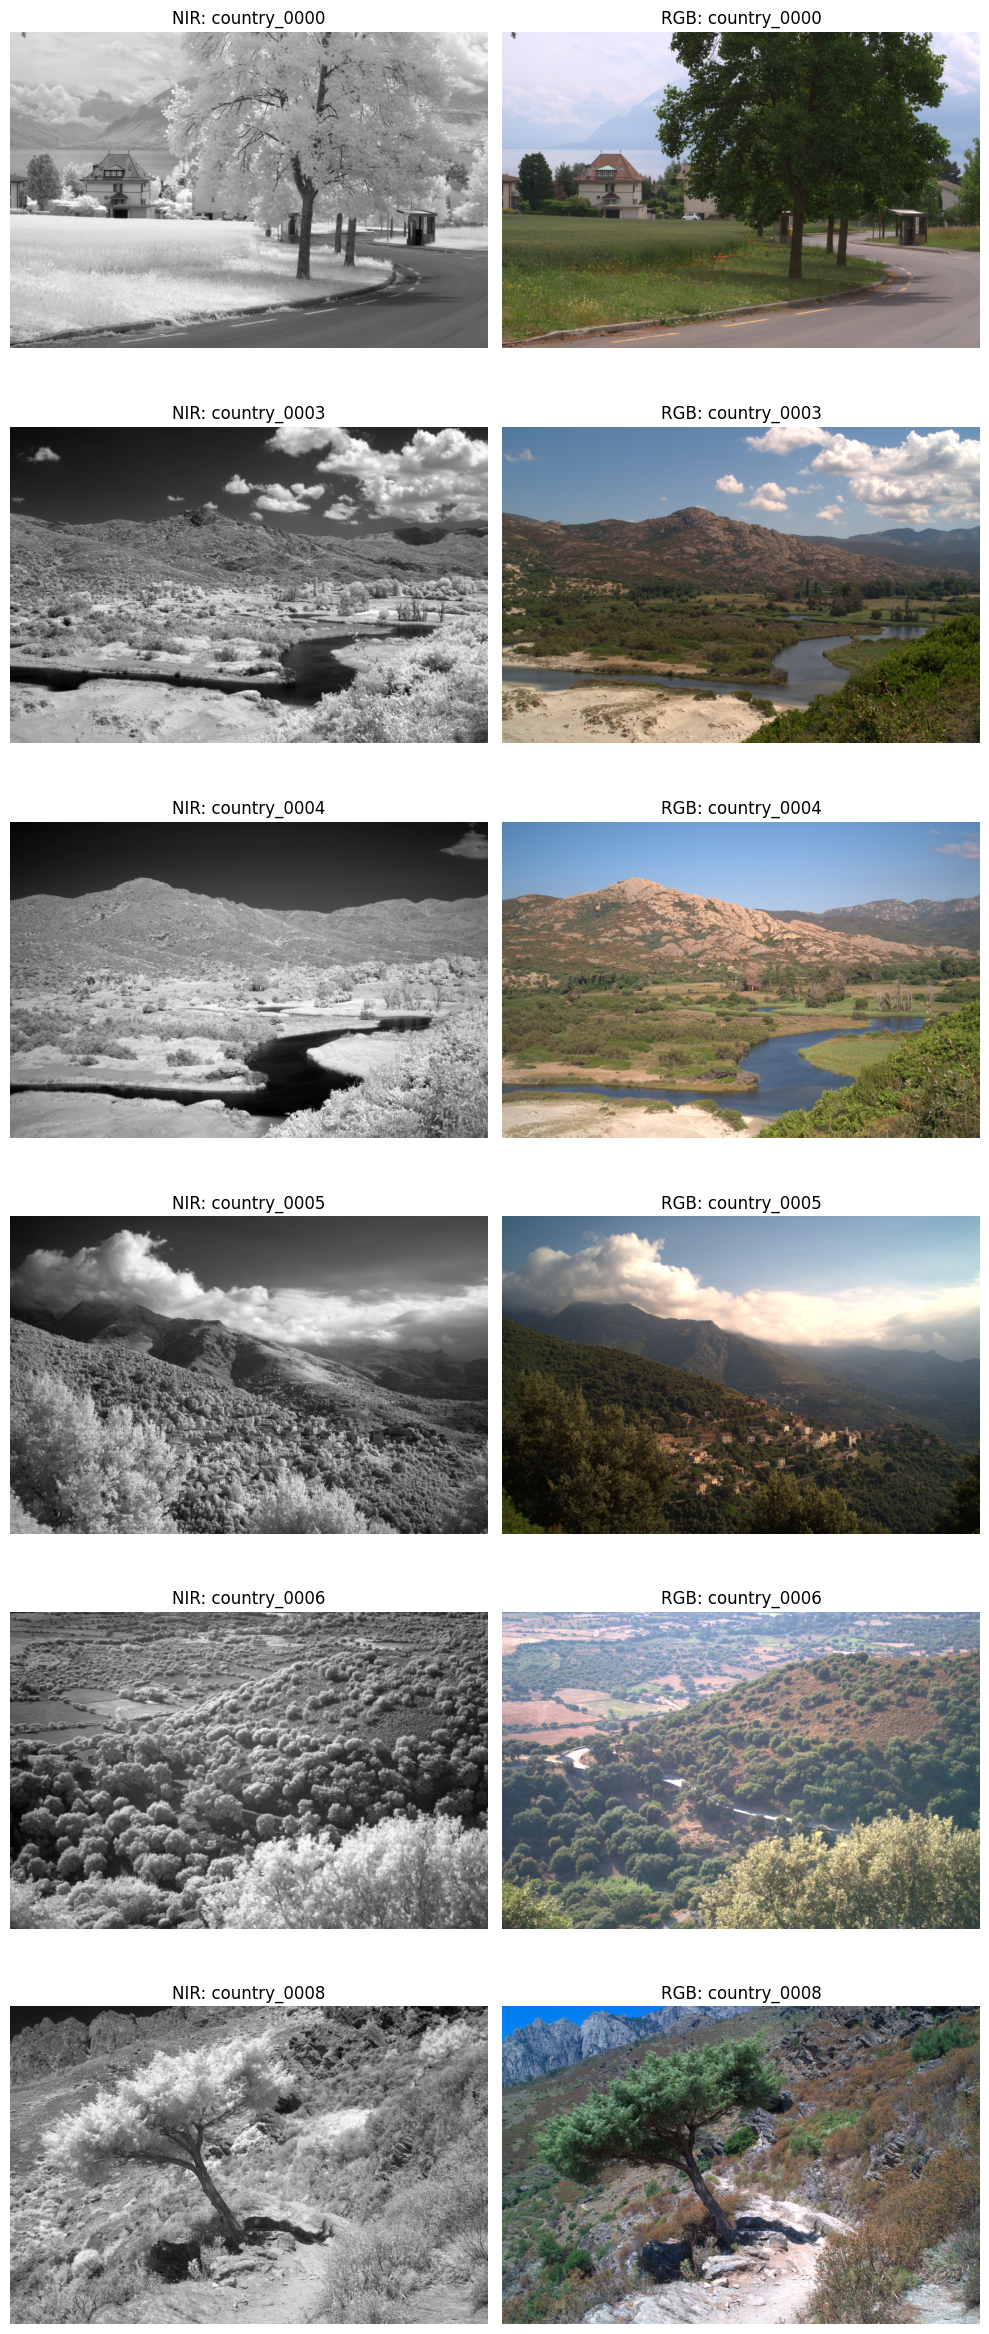

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

split = "train"

rgb_dir = DATASET_ROOT / split / "rgb"
nir_dir = DATASET_ROOT / split / "nir"

rgb_files = get_normalized_files(rgb_dir, "_rgb")
nir_files = get_normalized_files(nir_dir, "_nir")

common_names = sorted(set(rgb_files) & set(nir_files))

# Inspect the first 6 paired samples
samples = common_names[:6]

fig, axes = plt.subplots(len(samples), 2, figsize=(10, 4 * len(samples)))

for row, name in enumerate(samples):

    nir_image = Image.open(nir_files[name]).convert("L")
    rgb_image = Image.open(rgb_files[name]).convert("RGB")

    axes[row, 0].imshow(nir_image, cmap="gray")
    axes[row, 0].set_title(f"NIR: {name}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(rgb_image)
    axes[row, 1].set_title(f"RGB: {name}")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

In [9]:
from pathlib import Path

PROJECT_ROOT = Path("/content/MP1_IR2RGB")

folders = [
    "data",
    "checkpoints",
    "outputs",
    "results",
    "src",
    "scripts",
    "configs",
]

for folder in folders:
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)

print("Project workspace created:")
print(PROJECT_ROOT)

print("\nFolders:")
for folder in folders:
    print(f"  ✓ {folder}")

Project workspace created:
/content/MP1_IR2RGB

Folders:
  ✓ data
  ✓ checkpoints
  ✓ outputs
  ✓ results
  ✓ src
  ✓ scripts
  ✓ configs


In [10]:

import torch
import platform

print("========== SYSTEM ==========")
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)

print("\n========== GPU ==========")
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())

    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}:", torch.cuda.get_device_name(i))

    print("CUDA version:", torch.version.cuda)
else:
    print("WARNING: GPU is not available.")
    print("Go to Runtime → Change runtime type → Hardware accelerator → GPU")

========== SYSTEM ==========
Python: 3.13.15
PyTorch: 2.11.0+cu128

========== GPU ==========
CUDA available: True
GPU count: 1
GPU 0: Tesla T4
CUDA version: 12.8


In [11]:
import torch
import torchvision
import numpy as np
from PIL import Image

print("========== ENVIRONMENT CHECK ==========")
print("Python       :", __import__("platform").python_version())
print("PyTorch      :", torch.__version__)
print("TorchVision  :", torchvision.__version__)
print("NumPy        :", np.__version__)
print("Pillow       :", Image.__version__)

print("\n========== CUDA CHECK ==========")
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 2),
        "GB"
    )

print("\n========== PROJECT CHECK ==========")

from pathlib import Path

PROJECT_ROOT = Path("/content/MP1_IR2RGB")

for folder in [
    "data",
    "checkpoints",
    "outputs",
    "results",
    "src",
    "scripts",
    "configs",
]:
    path = PROJECT_ROOT / folder
    print(f"{folder:12s}:", "PASS" if path.exists() else "MISSING")

print("\n========== DATASET CHECK ==========")

DATASET_ROOT = Path(
    "/content/drive/MyDrive/AI-Workspace/Projects/"
    "foundation-model-visible-thermal-translation/"
    "datasets/processed/EPFL_RGB_NIR"
)

print("Dataset exists:", DATASET_ROOT.exists())
print("Dataset path  :", DATASET_ROOT)

for split in ["train", "val", "test"]:
    rgb = DATASET_ROOT / split / "rgb"
    nir = DATASET_ROOT / split / "nir"

    print(
        f"{split:5s}:",
        "RGB =", rgb.exists(),
        "| NIR =", nir.exists()
    )

========== ENVIRONMENT CHECK ==========
Python       : 3.13.15
PyTorch      : 2.11.0+cu128
TorchVision  : 0.26.0+cu128
NumPy        : 2.1.3
Pillow       : 11.3.0

========== CUDA CHECK ==========
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB

========== PROJECT CHECK ==========
data        : PASS
checkpoints : PASS
outputs     : PASS
results     : PASS
src         : PASS
scripts     : PASS
configs     : PASS

========== DATASET CHECK ==========
Dataset exists: True
Dataset path  : /content/drive/MyDrive/AI-Workspace/Projects/foundation-model-visible-thermal-translation/datasets/processed/EPFL_RGB_NIR
train: RGB = True | NIR = True
val  : RGB = True | NIR = True
test : RGB = True | NIR = True


In [12]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive", force_remount=True)

DRIVE_ROOT = Path("/content/drive/MyDrive")

print("Drive mounted:", DRIVE_ROOT.exists())
print("Drive root:", DRIVE_ROOT)

Mounted at /content/drive
Drive mounted: True
Drive root: /content/drive/MyDrive


In [13]:
from pathlib import Path

PROJECT_ROOT = Path("/content/MP1_IR2RGB")

folders = [
    "data",
    "checkpoints",
    "outputs",
    "results",
    "src",
    "scripts",
    "configs",
]

for folder in folders:
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)

print("Project workspace:", PROJECT_ROOT)
print()

for folder in folders:
    path = PROJECT_ROOT / folder
    print(f"{folder:12s}: {'PASS' if path.exists() else 'FAIL'}")

Project workspace: /content/MP1_IR2RGB

data        : PASS
checkpoints : PASS
outputs     : PASS
results     : PASS
src         : PASS
scripts     : PASS
configs     : PASS


In [14]:
from pathlib import Path

DRIVE_ROOT = Path("/content/drive/MyDrive")

print("Searching for EPFL RGB-NIR dataset...\n")

candidates = []

for p in DRIVE_ROOT.rglob("*"):
    if p.is_dir() and "EPFL_RGB_NIR".lower() == p.name.lower():
        candidates.append(p)

if candidates:
    print("Found dataset location(s):\n")
    for i, path in enumerate(candidates, 1):
        print(f"{i}. {path}")
else:
    print("EPFL_RGB_NIR dataset was NOT found.")

Searching for EPFL RGB-NIR dataset...

Found dataset location(s):

1. /content/drive/MyDrive/AI-Workspace/Datasets/EPFL_RGB_NIR
2. /content/drive/MyDrive/AI-Workspace/Projects/foundation-model-visible-thermal-translation/datasets/processed/EPFL_RGB_NIR


In [15]:
from pathlib import Path

required_splits = ["train", "val", "test"]
required_modalities = ["rgb", "nir"]

valid_candidates = []

for candidate in candidates:

    valid = True

    for split in required_splits:
        for modality in required_modalities:
            folder = candidate / split / modality

            if not folder.exists():
                valid = False

    if valid:
        valid_candidates.append(candidate)

print("Valid EPFL dataset candidates:")

for path in valid_candidates:
    print("PASS:", path)

if not valid_candidates:
    raise FileNotFoundError(
        "No EPFL dataset with train/val/test RGB/NIR structure was found."
    )

DATASET_ROOT = valid_candidates[0]

print("\nSELECTED DATASET:")
print(DATASET_ROOT)

Valid EPFL dataset candidates:
PASS: /content/drive/MyDrive/AI-Workspace/Projects/foundation-model-visible-thermal-translation/datasets/processed/EPFL_RGB_NIR

SELECTED DATASET:
/content/drive/MyDrive/AI-Workspace/Projects/foundation-model-visible-thermal-translation/datasets/processed/EPFL_RGB_NIR


In [16]:
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff"
}

for split in ["train", "val", "test"]:

    print(f"\n========== {split.upper()} ==========")

    for modality in ["rgb", "nir"]:

        folder = DATASET_ROOT / split / modality

        images = [
            p for p in folder.rglob("*")
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        ]

        print(f"{modality.upper():5s}: {len(images)} images")


========== TRAIN ==========
RGB  : 334 images
NIR  : 334 images

========== VAL ==========
RGB  : 71 images
NIR  : 71 images

========== TEST ==========
RGB  : 72 images
NIR  : 72 images


In [17]:
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff"
}

def get_normalized_files(folder, suffix):
    files = {}

    for p in folder.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
            if p.stem.endswith(suffix):
                pair_id = p.stem[:-len(suffix)]
                files[pair_id] = p

    return files


all_pair_checks_passed = True

for split in ["train", "val", "test"]:

    rgb_files = get_normalized_files(
        DATASET_ROOT / split / "rgb",
        "_rgb"
    )

    nir_files = get_normalized_files(
        DATASET_ROOT / split / "nir",
        "_nir"
    )

    rgb_ids = set(rgb_files.keys())
    nir_ids = set(nir_files.keys())

    common_ids = rgb_ids & nir_ids
    rgb_only = rgb_ids - nir_ids
    nir_only = nir_ids - rgb_ids

    passed = (
        len(rgb_only) == 0
        and len(nir_only) == 0
        and len(rgb_ids) == len(nir_ids) == len(common_ids)
    )

    if not passed:
        all_pair_checks_passed = False

    print(f"\n========== {split.upper()} ==========")
    print("RGB:", len(rgb_ids))
    print("NIR:", len(nir_ids))
    print("Matched pairs:", len(common_ids))
    print("RGB without NIR:", len(rgb_only))
    print("NIR without RGB:", len(nir_only))
    print("STATUS:", "PASS" if passed else "FAIL")

print("\n===================================")
print(
    "OVERALL DATASET PAIRING:",
    "PASS" if all_pair_checks_passed else "FAIL"
)
print("===================================")


========== TRAIN ==========
RGB: 334
NIR: 334
Matched pairs: 334
RGB without NIR: 0
NIR without RGB: 0
STATUS: PASS

========== VAL ==========
RGB: 71
NIR: 71
Matched pairs: 71
RGB without NIR: 0
NIR without RGB: 0
STATUS: PASS

========== TEST ==========
RGB: 72
NIR: 72
Matched pairs: 72
RGB without NIR: 0
NIR without RGB: 0
STATUS: PASS

OVERALL DATASET PAIRING: PASS


In [18]:
import shutil
from pathlib import Path

LOCAL_DATASET = PROJECT_ROOT / "data" / "EPFL_RGB_NIR"

print("Source dataset:")
print(DATASET_ROOT)

print("\nLocal dataset:")
print(LOCAL_DATASET)

if LOCAL_DATASET.exists():
    print("\nLocal dataset already exists.")
    print("Skipping copy.")
else:
    print("\nCopying dataset from Google Drive to Colab...")
    shutil.copytree(DATASET_ROOT, LOCAL_DATASET)
    print("Dataset copied successfully.")

print("\nLocal dataset exists:", LOCAL_DATASET.exists())

Source dataset:
/content/drive/MyDrive/AI-Workspace/Projects/foundation-model-visible-thermal-translation/datasets/processed/EPFL_RGB_NIR

Local dataset:
/content/MP1_IR2RGB/data/EPFL_RGB_NIR

Copying dataset from Google Drive to Colab...
Dataset copied successfully.

Local dataset exists: True


In [19]:
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff"
}

for split in ["train", "val", "test"]:

    print(f"\n========== {split.upper()} ==========")

    for modality in ["rgb", "nir"]:

        folder = LOCAL_DATASET / split / modality

        images = [
            p for p in folder.rglob("*")
            if p.is_file()
            and p.suffix.lower() in IMAGE_EXTENSIONS
        ]

        print(f"{modality.upper():5s}: {len(images)} images")


========== TRAIN ==========
RGB  : 334 images
NIR  : 334 images

========== VAL ==========
RGB  : 71 images
NIR  : 71 images

========== TEST ==========
RGB  : 72 images
NIR  : 72 images


In [20]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path


class EPFLIR2RGBDataset(Dataset):
    """
    Paired NIR -> RGB dataset.

    Input:
        NIR image

    Target:
        Corresponding RGB image
    """

    IMAGE_EXTENSIONS = {
        ".jpg", ".jpeg", ".png",
        ".bmp", ".tif", ".tiff"
    }

    def __init__(self, root, split="train", image_size=256):

        self.root = Path(root)
        self.split = split
        self.image_size = image_size

        self.nir_dir = self.root / split / "nir"
        self.rgb_dir = self.root / split / "rgb"

        if not self.nir_dir.exists():
            raise FileNotFoundError(
                f"NIR directory not found: {self.nir_dir}"
            )

        if not self.rgb_dir.exists():
            raise FileNotFoundError(
                f"RGB directory not found: {self.rgb_dir}"
            )

        self.nir_files = self._get_files(self.nir_dir, "_nir")
        self.rgb_files = self._get_files(self.rgb_dir, "_rgb")

        nir_ids = set(self.nir_files.keys())
        rgb_ids = set(self.rgb_files.keys())

        if nir_ids != rgb_ids:
            missing_rgb = sorted(nir_ids - rgb_ids)
            missing_nir = sorted(rgb_ids - nir_ids)

            raise RuntimeError(
                f"Pairing mismatch.\n"
                f"Missing RGB: {missing_rgb[:5]}\n"
                f"Missing NIR: {missing_nir[:5]}"
            )

        self.pair_ids = sorted(nir_ids)

        self.nir_transform = transforms.Compose([
            transforms.Resize(
                (image_size, image_size),
                antialias=True
            ),
            transforms.ToTensor(),
        ])

        self.rgb_transform = transforms.Compose([
            transforms.Resize(
                (image_size, image_size),
                antialias=True
            ),
            transforms.ToTensor(),
        ])

    def _get_files(self, folder, suffix):

        files = {}

        for path in folder.rglob("*"):

            if (
                path.is_file()
                and path.suffix.lower() in self.IMAGE_EXTENSIONS
                and path.stem.endswith(suffix)
            ):
                pair_id = path.stem[:-len(suffix)]
                files[pair_id] = path

        return files

    def __len__(self):
        return len(self.pair_ids)

    def __getitem__(self, index):

        pair_id = self.pair_ids[index]

        nir_path = self.nir_files[pair_id]
        rgb_path = self.rgb_files[pair_id]

        nir_image = Image.open(nir_path).convert("L")
        rgb_image = Image.open(rgb_path).convert("RGB")

        nir_tensor = self.nir_transform(nir_image)
        rgb_tensor = self.rgb_transform(rgb_image)

        return {
            "nir": nir_tensor,
            "rgb": rgb_tensor,
            "id": pair_id,
        }

In [21]:
train_dataset = EPFLIR2RGBDataset(
    root=LOCAL_DATASET,
    split="train",
    image_size=256
)

val_dataset = EPFLIR2RGBDataset(
    root=LOCAL_DATASET,
    split="val",
    image_size=256
)

test_dataset = EPFLIR2RGBDataset(
    root=LOCAL_DATASET,
    split="test",
    image_size=256
)

print("========== DATASET SIZES ==========")
print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))

========== DATASET SIZES ==========
Train: 334
Val  : 71
Test : 72


In [22]:
BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

batch = next(iter(train_loader))

print("========== BATCH CHECK ==========")
print("NIR shape :", batch["nir"].shape)
print("RGB shape :", batch["rgb"].shape)
print("IDs       :", batch["id"][:4])

print("\n========== VALUE RANGE ==========")
print(
    "NIR:",
    float(batch["nir"].min()),
    "to",
    float(batch["nir"].max())
)

print(
    "RGB:",
    float(batch["rgb"].min()),
    "to",
    float(batch["rgb"].max())
)

========== BATCH CHECK ==========
NIR shape : torch.Size([4, 1, 256, 256])
RGB shape : torch.Size([4, 3, 256, 256])
IDs       : ['oldbuilding_0076', 'forest_0013', 'country_0010', 'country_0070']

========== VALUE RANGE ==========
NIR: 0.03529411926865578 to 1.0
RGB: 0.0 to 1.0


baseline model

In [28]:
import torch
import torch.nn as nn


class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = ConvBlock(
            in_channels,
            out_channels
        )

        self.pool = nn.MaxPool2d(2)

    def forward(self, x):

        features = self.conv(x)
        down = self.pool(features)

        return features, down


class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = ConvBlock(
            out_channels + skip_channels,
            out_channels
        )

    def forward(self, x, skip):

        x = self.up(x)

        # Handle any spatial-size mismatch caused by resizing.
        if x.shape[-2:] != skip.shape[-2:]:
            x = nn.functional.interpolate(
                x,
                size=skip.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

        x = torch.cat([x, skip], dim=1)

        return self.conv(x)


class IR2RGBUNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.down1 = DownBlock(1, 64)
        self.down2 = DownBlock(64, 128)
        self.down3 = DownBlock(128, 256)
        self.down4 = DownBlock(256, 512)

        # Bottleneck
        self.bottleneck = ConvBlock(512, 1024)

        # Decoder
        self.up4 = UpBlock(1024, 512, 512)
        self.up3 = UpBlock(512, 256, 256)
        self.up2 = UpBlock(256, 128, 128)
        self.up1 = UpBlock(128, 64, 64)

        # RGB output
        self.output = nn.Sequential(
            nn.Conv2d(
                64,
                3,
                kernel_size=1
            ),
            nn.Sigmoid()
        )

    def forward(self, x):

        skip1, x = self.down1(x)
        skip2, x = self.down2(x)
        skip3, x = self.down3(x)
        skip4, x = self.down4(x)

        x = self.bottleneck(x)

        x = self.up4(x, skip4)
        x = self.up3(x, skip3)
        x = self.up2(x, skip2)
        x = self.up1(x, skip1)

        return self.output(x)

In [29]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = IR2RGBUNet().to(device)

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("========== MODEL ==========")
print("Model:", model.__class__.__name__)
print("Device:", device)

print("\nTotal parameters:",
      f"{total_parameters:,}")

print("Trainable parameters:",
      f"{trainable_parameters:,}")

print(
    "Approx. parameter memory:",
    round(
        total_parameters * 4 / (1024 ** 2),
        2
    ),
    "MB"
)

========== MODEL ==========
Model: IR2RGBUNet
Device: cuda

Total parameters: 31,042,499
Trainable parameters: 31,042,499
Approx. parameter memory: 118.42 MB


In [30]:
model.eval()

batch = next(iter(train_loader))

nir = batch["nir"].to(device)
rgb = batch["rgb"].to(device)

with torch.no_grad():
    generated_rgb = model(nir)

print("========== FORWARD PASS ==========")
print("Input NIR :", nir.shape)
print("Target RGB:", rgb.shape)
print("Generated :", generated_rgb.shape)

print("\n========== OUTPUT RANGE ==========")
print(
    "Generated RGB:",
    float(generated_rgb.min()),
    "to",
    float(generated_rgb.max())
)

print("\n========== DEVICE ==========")
print("Input device:", nir.device)
print("Model device:", next(model.parameters()).device)

print("\nSTATUS: PASS")

========== FORWARD PASS ==========
Input NIR : torch.Size([4, 1, 256, 256])
Target RGB: torch.Size([4, 3, 256, 256])
Generated : torch.Size([4, 3, 256, 256])

========== OUTPUT RANGE ==========
Generated RGB: 0.4657723307609558 to 0.5005233287811279

========== DEVICE ==========
Input device: cuda:0
Model device: cuda:0

STATUS: PASS


In [31]:
import torch
import torch.nn as nn

# Reconstruction loss
criterion = nn.L1Loss()

# Adam optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

print("========== TRAINING OBJECTIVE ==========")
print("Loss      : L1 reconstruction loss")
print("Optimizer : Adam")
print("Learning rate:", 2e-4)
print("Betas     :", (0.5, 0.999))

========== TRAINING OBJECTIVE ==========
Loss      : L1 reconstruction loss
Optimizer : Adam
Learning rate: 0.0002
Betas     : (0.5, 0.999)


In [32]:
model.train()

batch = next(iter(train_loader))

nir = batch["nir"].to(device, non_blocking=True)
rgb = batch["rgb"].to(device, non_blocking=True)

optimizer.zero_grad(set_to_none=True)

generated_rgb = model(nir)

loss = criterion(generated_rgb, rgb)

loss.backward()

optimizer.step()

print("========== ONE TRAINING STEP ==========")
print("NIR shape       :", nir.shape)
print("RGB shape       :", rgb.shape)
print("Generated shape :", generated_rgb.shape)
print("L1 loss         :", float(loss.item()))

print("\nGPU:")
print("Input device    :", nir.device)
print("Model device    :", next(model.parameters()).device)

print("\nSTATUS: PASS")

========== ONE TRAINING STEP ==========
NIR shape       : torch.Size([4, 1, 256, 256])
RGB shape       : torch.Size([4, 3, 256, 256])
Generated shape : torch.Size([4, 3, 256, 256])
L1 loss         : 0.19794762134552002

GPU:
Input device    : cuda:0
Model device    : cuda:0

STATUS: PASS


In [33]:
if torch.cuda.is_available():

    allocated = torch.cuda.memory_allocated(0) / (1024 ** 3)
    reserved = torch.cuda.memory_reserved(0) / (1024 ** 3)

    print("========== GPU MEMORY ==========")
    print(f"Allocated: {allocated:.2f} GB")
    print(f"Reserved : {reserved:.2f} GB")

    print("\nSTATUS: GPU training step completed successfully.")

========== GPU MEMORY ==========
Allocated: 0.48 GB
Reserved : 2.27 GB

STATUS: GPU training step completed successfully.


In [34]:
from torch.utils.data import DataLoader

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("========== VALIDATION LOADER ==========")
print("Validation samples:", len(val_dataset))
print("Validation batches :", len(val_loader))
print("Batch size         :", 4)

========== VALIDATION LOADER ==========
Validation samples: 71
Validation batches : 18
Batch size         : 4


In [35]:
import time
from pathlib import Path

NUM_EPOCHS = 5

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

best_val_loss = float("inf")

history = []

print("========== BASELINE TRAINING ==========")
print("Model      :", model.__class__.__name__)
print("Device     :", device)
print("Epochs     :", NUM_EPOCHS)
print("Batch size :", 4)
print("Loss       : L1")
print("Learning rate:", 2e-4)

for epoch in range(1, NUM_EPOCHS + 1):

    epoch_start = time.time()

    # -------------------------
    # Training
    # -------------------------
    model.train()

    train_loss_sum = 0.0
    train_samples = 0

    for batch in train_loader:

        nir = batch["nir"].to(
            device,
            non_blocking=True
        )

        rgb = batch["rgb"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        generated_rgb = model(nir)

        loss = criterion(
            generated_rgb,
            rgb
        )

        loss.backward()
        optimizer.step()

        batch_size = nir.size(0)

        train_loss_sum += (
            loss.item() * batch_size
        )

        train_samples += batch_size

    train_loss = (
        train_loss_sum / train_samples
    )

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_loss_sum = 0.0
    val_samples = 0

    with torch.no_grad():

        for batch in val_loader:

            nir = batch["nir"].to(
                device,
                non_blocking=True
            )

            rgb = batch["rgb"].to(
                device,
                non_blocking=True
            )

            generated_rgb = model(nir)

            loss = criterion(
                generated_rgb,
                rgb
            )

            batch_size = nir.size(0)

            val_loss_sum += (
                loss.item() * batch_size
            )

            val_samples += batch_size

    val_loss = (
        val_loss_sum / val_samples
    )

    epoch_time = time.time() - epoch_start

    history.append({
        "epoch": epoch,
        "train_l1": train_loss,
        "val_l1": val_loss,
        "time_seconds": epoch_time
    })

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train L1: {train_loss:.6f} | "
        f"Val L1: {val_loss:.6f} | "
        f"Time: {epoch_time:.1f}s"
    )

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        checkpoint_path = (
            CHECKPOINT_DIR /
            "baseline_best.pth"
        )

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_l1": train_loss,
            "val_l1": val_loss,
        }, checkpoint_path)

        print(
            f"  ✓ Best checkpoint saved: "
            f"{checkpoint_path}"
        )

print("\n========== TRAINING COMPLETE ==========")
print("Best validation L1:", best_val_loss)

========== BASELINE TRAINING ==========
Model      : IR2RGBUNet
Device     : cuda
Epochs     : 5
Batch size : 4
Loss       : L1
Learning rate: 0.0002
Epoch 01/5 | Train L1: 0.164019 | Val L1: 0.151796 | Time: 22.5s
  ✓ Best checkpoint saved: /content/MP1_IR2RGB/checkpoints/baseline_best.pth
Epoch 02/5 | Train L1: 0.152529 | Val L1: 0.139311 | Time: 23.9s
  ✓ Best checkpoint saved: /content/MP1_IR2RGB/checkpoints/baseline_best.pth
Epoch 03/5 | Train L1: 0.150250 | Val L1: 0.154507 | Time: 23.8s
Epoch 04/5 | Train L1: 0.146082 | Val L1: 0.134636 | Time: 23.0s
  ✓ Best checkpoint saved: /content/MP1_IR2RGB/checkpoints/baseline_best.pth
Epoch 05/5 | Train L1: 0.146778 | Val L1: 0.153637 | Time: 23.3s

========== TRAINING COMPLETE ==========
Best validation L1: 0.134635785620817


In [36]:
import pandas as pd

history_df = pd.DataFrame(history)

history_path = (
    PROJECT_ROOT /
    "results" /
    "baseline_training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

print("========== TRAINING HISTORY ==========")
print(history_df.to_string(index=False))

print("\nSaved to:")
print(history_path)

========== TRAINING HISTORY ==========
 epoch  train_l1   val_l1  time_seconds
     1  0.164019 0.151796     22.479675
     2  0.152529 0.139311     23.922502
     3  0.150250 0.154507     23.809285
     4  0.146082 0.134636     23.029720
     5  0.146778 0.153637     23.264282

Saved to:
/content/MP1_IR2RGB/results/baseline_training_history.csv


In [37]:
import torch

checkpoint_path = PROJECT_ROOT / "checkpoints" / "baseline_best.pth"

print("Checkpoint exists:", checkpoint_path.exists())
print("Checkpoint path:", checkpoint_path)

if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Best checkpoint not found: {checkpoint_path}"
    )

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("\n========== CHECKPOINT ==========")
print("Saved epoch     :", checkpoint["epoch"])
print("Train L1        :", checkpoint["train_l1"])
print("Validation L1   :", checkpoint["val_l1"])
print("Model loaded    : PASS")

Checkpoint exists: True
Checkpoint path: /content/MP1_IR2RGB/checkpoints/baseline_best.pth

========== CHECKPOINT ==========
Saved epoch     : 4
Train L1        : 0.1460818872748021
Validation L1   : 0.134635785620817
Model loaded    : PASS


In [38]:
test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("========== TEST SET ==========")
print("Test samples :", len(test_dataset))
print("Test batches :", len(test_loader))
print("Batch size   :", 4)

========== TEST SET ==========
Test samples : 72
Test batches : 18
Batch size   : 4


In [39]:
import torch

model.eval()

test_l1_sum = 0.0
test_samples = 0

all_predictions = []
all_targets = []
all_ids = []

with torch.no_grad():

    for batch in test_loader:

        nir = batch["nir"].to(
            device,
            non_blocking=True
        )

        rgb = batch["rgb"].to(
            device,
            non_blocking=True
        )

        generated_rgb = model(nir)

        loss = criterion(
            generated_rgb,
            rgb
        )

        batch_size = nir.size(0)

        test_l1_sum += (
            loss.item() * batch_size
        )

        test_samples += batch_size

        all_predictions.append(
            generated_rgb.cpu()
        )

        all_targets.append(
            rgb.cpu()
        )

        all_ids.extend(
            batch["id"]
        )

test_l1 = test_l1_sum / test_samples

all_predictions = torch.cat(
    all_predictions,
    dim=0
)

all_targets = torch.cat(
    all_targets,
    dim=0
)

print("========== TEST INFERENCE ==========")
print("Test samples processed:", test_samples)
print("Prediction tensor     :", all_predictions.shape)
print("Target tensor         :", all_targets.shape)
print("Test L1               :", test_l1)

print("\nSTATUS: PASS")

========== TEST INFERENCE ==========
Test samples processed: 72
Prediction tensor     : torch.Size([72, 3, 256, 256])
Target tensor         : torch.Size([72, 3, 256, 256])
Test L1               : 0.14396918192505836

STATUS: PASS


In [40]:
import importlib.util

packages = {
    "skimage": "scikit-image",
    "torchmetrics": "torchmetrics"
}

for module, package in packages.items():
    installed = importlib.util.find_spec(module) is not None
    print(
        f"{package:15s}:",
        "INSTALLED" if installed else "MISSING"
    )

scikit-image   : INSTALLED
torchmetrics   : MISSING


In [41]:
import numpy as np
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

predictions = all_predictions.numpy()
targets = all_targets.numpy()

psnr_scores = []
ssim_scores = []

for i in range(len(predictions)):

    # Convert CHW → HWC
    pred = np.transpose(
        predictions[i],
        (1, 2, 0)
    )

    target = np.transpose(
        targets[i],
        (1, 2, 0)
    )

    # PSNR
    psnr = peak_signal_noise_ratio(
        target,
        pred,
        data_range=1.0
    )

    # SSIM
    ssim = structural_similarity(
        target,
        pred,
        data_range=1.0,
        channel_axis=2
    )

    psnr_scores.append(psnr)
    ssim_scores.append(ssim)

mean_psnr = float(np.mean(psnr_scores))
mean_ssim = float(np.mean(ssim_scores))

print("========== IMAGE QUALITY METRICS ==========")
print(f"Mean PSNR : {mean_psnr:.4f} dB")
print(f"Mean SSIM : {mean_ssim:.4f}")

print("\nNumber of evaluated images:", len(psnr_scores))

========== IMAGE QUALITY METRICS ==========
Mean PSNR : 15.4673 dB
Mean SSIM : 0.6120

Number of evaluated images: 72


In [42]:
print("========== METRIC DISTRIBUTION ==========")

print(
    f"PSNR: "
    f"min={np.min(psnr_scores):.4f}, "
    f"max={np.max(psnr_scores):.4f}, "
    f"mean={np.mean(psnr_scores):.4f}, "
    f"std={np.std(psnr_scores):.4f}"
)

print(
    f"SSIM: "
    f"min={np.min(ssim_scores):.4f}, "
    f"max={np.max(ssim_scores):.4f}, "
    f"mean={np.mean(ssim_scores):.4f}, "
    f"std={np.std(ssim_scores):.4f}"
)

========== METRIC DISTRIBUTION ==========
PSNR: min=10.7736, max=21.8246, mean=15.4673, std=2.5561
SSIM: min=0.3376, max=0.8236, mean=0.6120, std=0.1245


In [98]:
!pip install -q lpips

In [44]:
import importlib.util

print("LPIPS installed:",
      importlib.util.find_spec("lpips") is not None)

LPIPS installed: True


In [45]:
import lpips
import torch

print("========== LPIPS CHECK ==========")
print("LPIPS version:", getattr(lpips, "__version__", "version not reported"))
print("CUDA available:", torch.cuda.is_available())
print("LPIPS import: PASS")

========== LPIPS CHECK ==========
LPIPS version: version not reported
CUDA available: True
LPIPS import: PASS


In [46]:
import torch
import lpips
import numpy as np

# Create LPIPS network
lpips_model = lpips.LPIPS(net="alex").to(device)
lpips_model.eval()

lpips_scores = []

print("Calculating LPIPS for 72 test images...")

with torch.no_grad():

    for i in range(len(all_predictions)):

        # LPIPS expects values in [-1, 1]
        pred = all_predictions[i:i+1].to(device)
        target = all_targets[i:i+1].to(device)

        pred_lpips = pred * 2.0 - 1.0
        target_lpips = target * 2.0 - 1.0

        score = lpips_model(
            pred_lpips,
            target_lpips
        )

        lpips_scores.append(
            float(score.item())
        )

mean_lpips = float(
    np.mean(lpips_scores)
)

print("\n========== LPIPS RESULTS ==========")
print(f"Mean LPIPS : {mean_lpips:.4f}")
print(f"Min LPIPS  : {np.min(lpips_scores):.4f}")
print(f"Max LPIPS  : {np.max(lpips_scores):.4f}")
print(f"Std LPIPS  : {np.std(lpips_scores):.4f}")

print("\nImages evaluated:", len(lpips_scores))

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 134MB/s]


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/alex.pth
Calculating LPIPS for 72 test images...

========== LPIPS RESULTS ==========
Mean LPIPS : 0.3833
Min LPIPS  : 0.1750
Max LPIPS  : 0.6150
Std LPIPS  : 0.1076

Images evaluated: 72


In [47]:
import pandas as pd
from pathlib import Path

results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(parents=True, exist_ok=True)

baseline_summary = pd.DataFrame([{
    "model": "IR2RGB_U-Net_Baseline",
    "epochs": 5,
    "train_samples": 334,
    "validation_samples": 71,
    "test_samples": 72,
    "test_l1": test_l1,
    "psnr_mean_db": mean_psnr,
    "psnr_std_db": float(np.std(psnr_scores)),
    "ssim_mean": mean_ssim,
    "ssim_std": float(np.std(ssim_scores)),
    "lpips_mean": mean_lpips,
    "lpips_std": float(np.std(lpips_scores)),
}])

summary_path = results_dir / "baseline_metrics_summary.csv"

baseline_summary.to_csv(
    summary_path,
    index=False
)

print("========== BASELINE RESULTS SAVED ==========")
print(baseline_summary.to_string(index=False))

print("\nSaved to:")
print(summary_path)

========== BASELINE RESULTS SAVED ==========
                model  epochs  train_samples  validation_samples  test_samples  test_l1  psnr_mean_db  psnr_std_db  ssim_mean  ssim_std  lpips_mean  lpips_std
IR2RGB_U-Net_Baseline       5            334                  71            72 0.143969     15.467329     2.556088   0.612007  0.124468    0.383317   0.107572

Saved to:
/content/MP1_IR2RGB/results/baseline_metrics_summary.csv


In [48]:
per_image_results = pd.DataFrame({
    "image_id": all_ids,
    "psnr_db": psnr_scores,
    "ssim": ssim_scores,
    "lpips": lpips_scores
})

per_image_path = (
    results_dir /
    "baseline_per_image_metrics.csv"
)

per_image_results.to_csv(
    per_image_path,
    index=False
)

print("========== PER-IMAGE RESULTS ==========")
print(per_image_results.head(10).to_string(index=False))

print("\nNumber of test images:",
      len(per_image_results))

print("\nSaved to:")
print(per_image_path)

========== PER-IMAGE RESULTS ==========
    image_id   psnr_db     ssim    lpips
country_0017 13.060963 0.459946 0.525302
country_0022 14.338061 0.579366 0.444206
country_0025 10.773557 0.608338 0.546944
country_0032 11.115424 0.537685 0.553811
country_0034 11.987583 0.421893 0.615000
country_0041 11.110554 0.337602 0.534696
country_0043 14.229254 0.417636 0.487670
country_0050 15.409870 0.444964 0.420637
  field_0012 14.754486 0.463835 0.421624
  field_0016 18.055106 0.395640 0.440398

Number of test images: 72

Saved to:
/content/MP1_IR2RGB/results/baseline_per_image_metrics.csv


In [49]:
import matplotlib.pyplot as plt
from PIL import Image

qualitative_dir = (
    results_dir /
    "qualitative_baseline"
)

qualitative_dir.mkdir(
    parents=True,
    exist_ok=True
)

model.eval()

# Select six representative test samples
selected_indices = [0, 10, 20, 30, 40, 50]

for idx in selected_indices:

    sample = test_dataset[idx]

    nir = sample["nir"].unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = model(nir)

    prediction = prediction.squeeze(0).cpu()

    nir_image = sample["nir"].permute(1, 2, 0).squeeze().numpy()
    target_image = sample["rgb"].permute(1, 2, 0).numpy()
    prediction_image = prediction.permute(1, 2, 0).numpy()

    image_id = sample["id"]

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    axes[0].imshow(
        nir_image,
        cmap="gray"
    )
    axes[0].set_title(
        f"NIR Input\n{image_id}"
    )
    axes[0].axis("off")

    axes[1].imshow(
        prediction_image
    )
    axes[1].set_title(
        "Generated RGB"
    )
    axes[1].axis("off")

    axes[2].imshow(
        target_image
    )
    axes[2].set_title(
        "Ground Truth RGB"
    )
    axes[2].axis("off")

    plt.tight_layout()

    save_path = (
        qualitative_dir /
        f"{image_id}_comparison.png"
    )

    plt.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

print("========== QUALITATIVE RESULTS ==========")
print("Saved comparison images to:")
print(qualitative_dir)

for path in sorted(qualitative_dir.glob("*.png")):
    print(path.name)

========== QUALITATIVE RESULTS ==========
Saved comparison images to:
/content/MP1_IR2RGB/results/qualitative_baseline
country_0017_comparison.png
field_0029_comparison.png
forest_0047_comparison.png
indoor_0035_comparison.png
mountain_0042_comparison.png
street_0037_comparison.png


Found 6 qualitative result images.


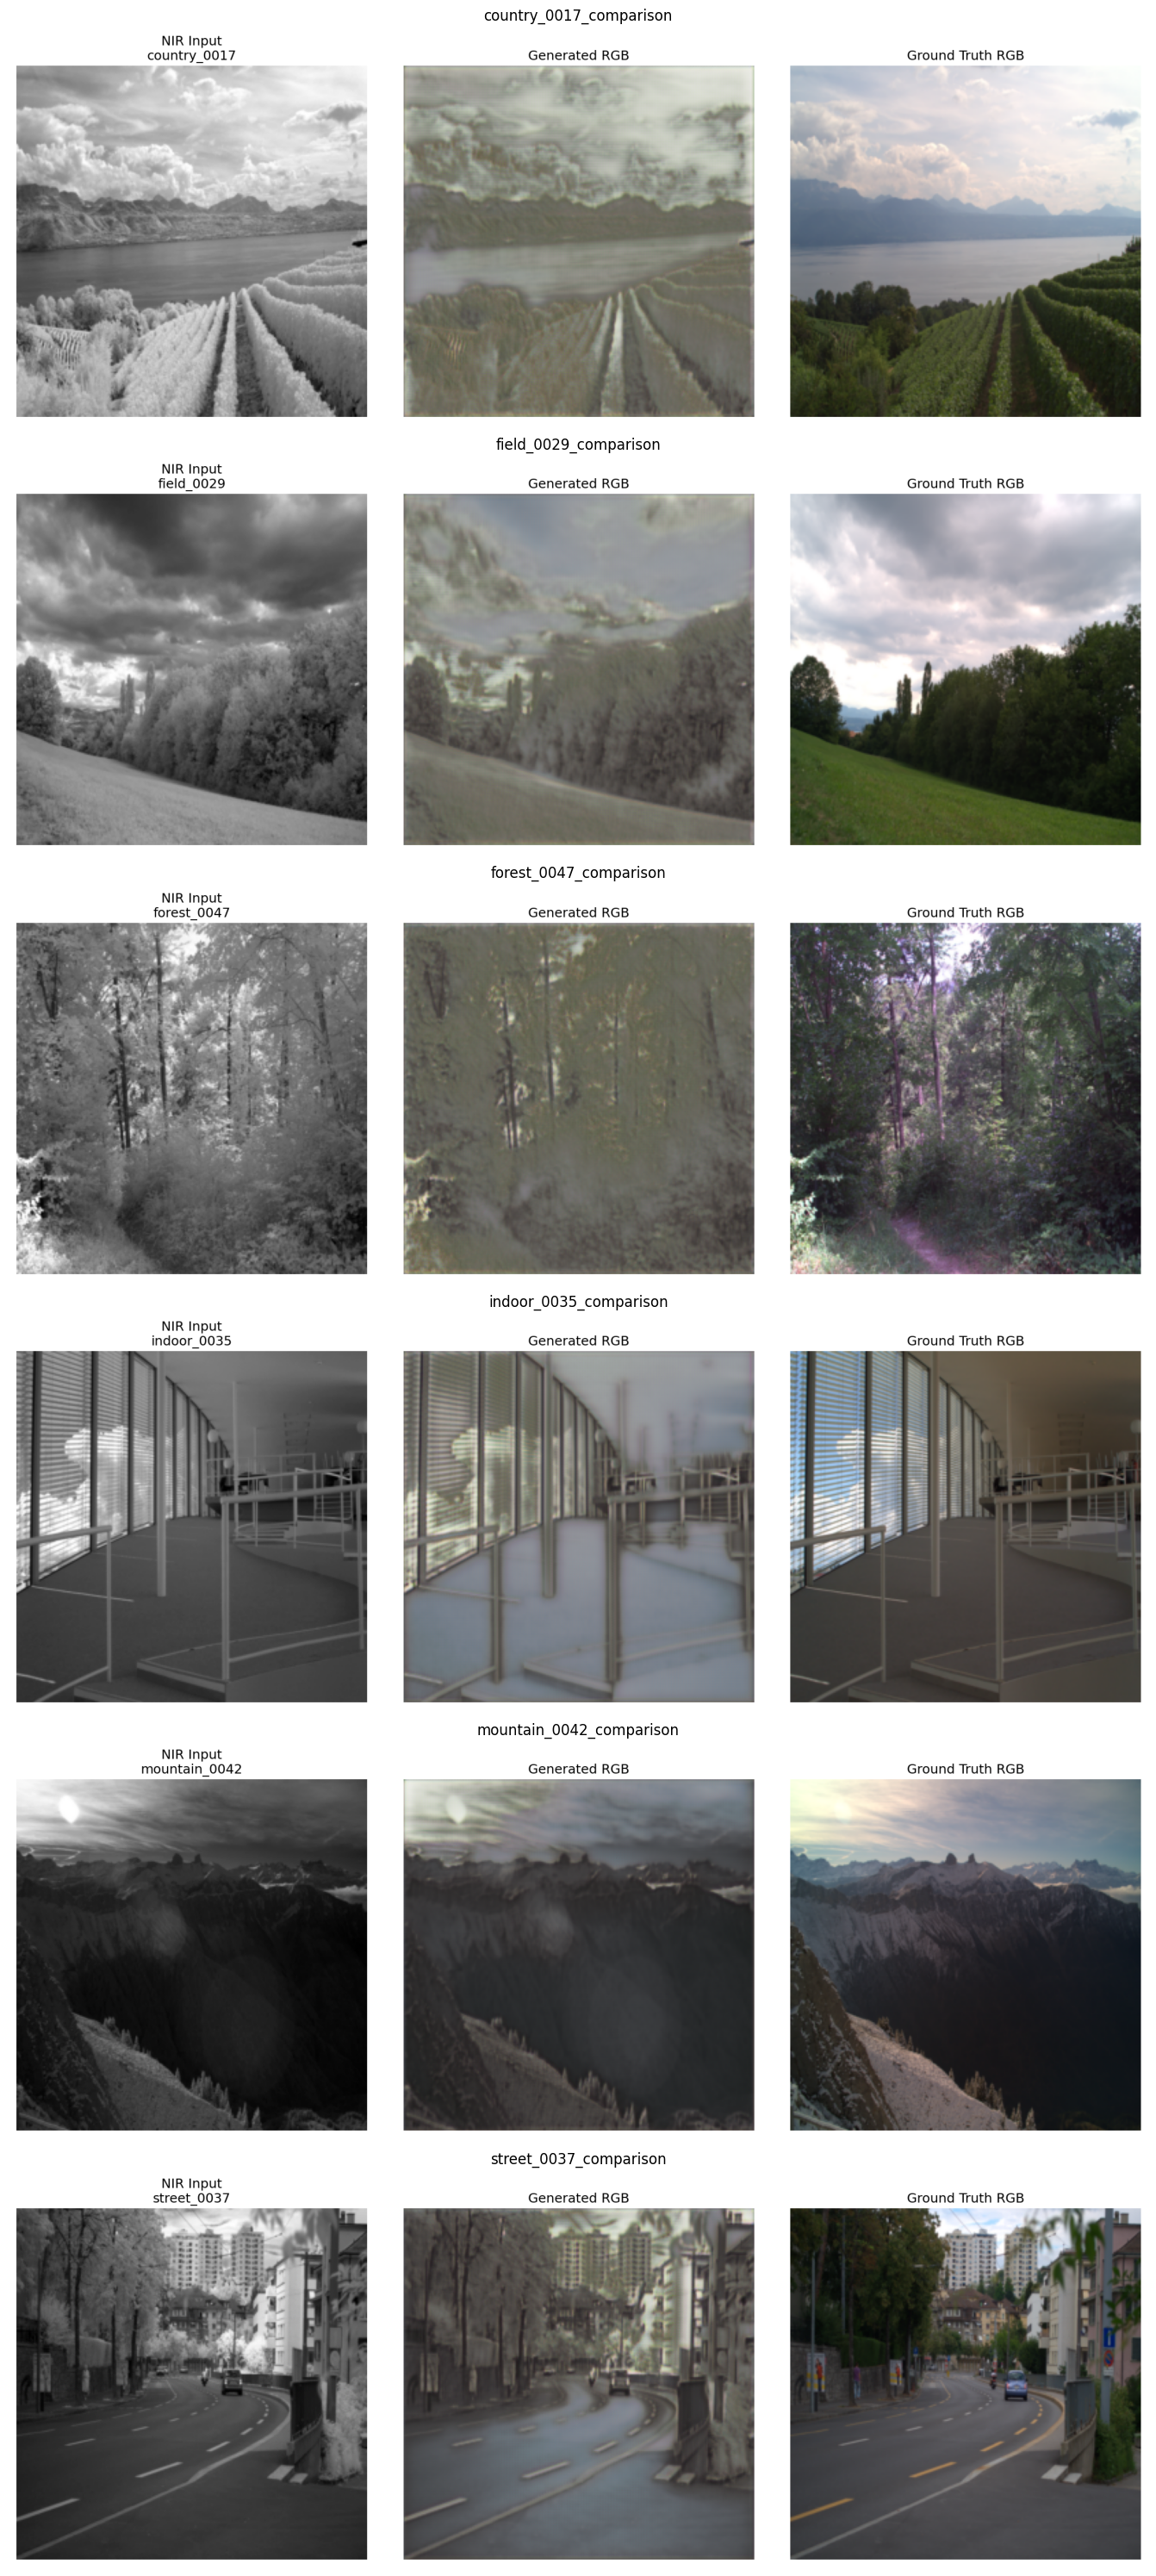


Saved contact sheet:
/content/MP1_IR2RGB/results/baseline_qualitative_contact_sheet.png


In [50]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

qualitative_dir = PROJECT_ROOT / "results" / "qualitative_baseline"

files = sorted(qualitative_dir.glob("*.png"))

print("Found", len(files), "qualitative result images.")

fig, axes = plt.subplots(
    len(files),
    1,
    figsize=(15, 5 * len(files))
)

if len(files) == 1:
    axes = [axes]

for ax, path in zip(axes, files):

    image = Image.open(path)

    ax.imshow(image)
    ax.set_title(path.stem)
    ax.axis("off")

plt.tight_layout()

contact_sheet_path = (
    PROJECT_ROOT /
    "results" /
    "baseline_qualitative_contact_sheet.png"
)

plt.savefig(
    contact_sheet_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\nSaved contact sheet:")
print(contact_sheet_path)

In [51]:
print("========== CURRENT BASELINE ==========")

print(f"Test L1  : {test_l1:.6f}")
print(f"PSNR     : {mean_psnr:.4f} dB")
print(f"SSIM     : {mean_ssim:.4f}")
print(f"LPIPS    : {mean_lpips:.4f}")

print("\nTest samples:", len(test_dataset))
print("Training epochs:", checkpoint["epoch"])
print("Checkpoint:", checkpoint_path)

========== CURRENT BASELINE ==========
Test L1  : 0.143969
PSNR     : 15.4673 dB
SSIM     : 0.6120
LPIPS    : 0.3833

Test samples: 72
Training epochs: 4
Checkpoint: /content/MP1_IR2RGB/checkpoints/baseline_best.pth


In [52]:

import torch
import time
import pandas as pd

# Load the best 5-epoch checkpoint
checkpoint_path = (
    PROJECT_ROOT /
    "checkpoints" /
    "baseline_best.pth"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

start_epoch = checkpoint["epoch"]

print("========== RESUME CHECK ==========")
print("Checkpoint epoch :", start_epoch)
print("Train L1         :", checkpoint["train_l1"])
print("Validation L1    :", checkpoint["val_l1"])
print("Model loaded     : PASS")
print("Optimizer loaded : PASS")

========== RESUME CHECK ==========
Checkpoint epoch : 4
Train L1         : 0.1460818872748021
Validation L1    : 0.134635785620817
Model loaded     : PASS
Optimizer loaded : PASS


In [53]:
TOTAL_EPOCHS = 30

best_val_loss_v2 = checkpoint["val_l1"]

history_v2 = []

# Keep the original 5 epochs in the history
history_v2.extend(history)

print("========== BASELINE V2 TRAINING ==========")
print(f"Continuing from epoch {start_epoch}")
print(f"Training until epoch {TOTAL_EPOCHS}")

for epoch in range(start_epoch + 1, TOTAL_EPOCHS + 1):

    epoch_start = time.time()

    # =========================
    # TRAINING
    # =========================
    model.train()

    train_loss_sum = 0.0
    train_samples = 0

    for batch in train_loader:

        nir = batch["nir"].to(
            device,
            non_blocking=True
        )

        rgb = batch["rgb"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        generated_rgb = model(nir)

        loss = criterion(
            generated_rgb,
            rgb
        )

        loss.backward()

        optimizer.step()

        batch_size = nir.size(0)

        train_loss_sum += (
            loss.item() * batch_size
        )

        train_samples += batch_size

    train_loss = (
        train_loss_sum /
        train_samples
    )

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    val_loss_sum = 0.0
    val_samples = 0

    with torch.no_grad():

        for batch in val_loader:

            nir = batch["nir"].to(
                device,
                non_blocking=True
            )

            rgb = batch["rgb"].to(
                device,
                non_blocking=True
            )

            generated_rgb = model(nir)

            loss = criterion(
                generated_rgb,
                rgb
            )

            batch_size = nir.size(0)

            val_loss_sum += (
                loss.item() * batch_size
            )

            val_samples += batch_size

    val_loss = (
        val_loss_sum /
        val_samples
    )

    epoch_time = time.time() - epoch_start

    history_v2.append({
        "epoch": epoch,
        "train_l1": train_loss,
        "val_l1": val_loss,
        "time_seconds": epoch_time
    })

    print(
        f"Epoch {epoch:02d}/{TOTAL_EPOCHS} | "
        f"Train L1: {train_loss:.6f} | "
        f"Val L1: {val_loss:.6f} | "
        f"Time: {epoch_time:.1f}s"
    )

    # =========================
    # SAVE BEST CHECKPOINT
    # =========================
    if val_loss < best_val_loss_v2:

        best_val_loss_v2 = val_loss

        best_checkpoint_path = (
            PROJECT_ROOT /
            "checkpoints" /
            "baseline_v2_best.pth"
        )

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_l1": train_loss,
            "val_l1": val_loss,
        }, best_checkpoint_path)

        print(
            "  ✓ New best checkpoint saved"
        )

print("\n========== BASELINE V2 COMPLETE ==========")
print(
    "Best validation L1:",
    best_val_loss_v2
)

========== BASELINE V2 TRAINING ==========
Continuing from epoch 4
Training until epoch 30
Epoch 05/30 | Train L1: 0.143150 | Val L1: 0.139127 | Time: 26.1s
Epoch 06/30 | Train L1: 0.142039 | Val L1: 0.142114 | Time: 24.2s
Epoch 07/30 | Train L1: 0.142015 | Val L1: 0.137277 | Time: 23.0s
Epoch 08/30 | Train L1: 0.140174 | Val L1: 0.132534 | Time: 23.6s
  ✓ New best checkpoint saved
Epoch 09/30 | Train L1: 0.136391 | Val L1: 0.151169 | Time: 23.7s
Epoch 10/30 | Train L1: 0.137166 | Val L1: 0.123929 | Time: 23.4s
  ✓ New best checkpoint saved
Epoch 11/30 | Train L1: 0.132813 | Val L1: 0.132093 | Time: 24.4s
Epoch 12/30 | Train L1: 0.137154 | Val L1: 0.126386 | Time: 23.4s
Epoch 13/30 | Train L1: 0.135454 | Val L1: 0.125708 | Time: 23.4s
Epoch 14/30 | Train L1: 0.133695 | Val L1: 0.121237 | Time: 23.8s
  ✓ New best checkpoint saved
Epoch 15/30 | Train L1: 0.132495 | Val L1: 0.125261 | Time: 23.4s
Epoch 16/30 | Train L1: 0.130602 | Val L1: 0.119105 | Time: 23.4s
  ✓ New best checkpoint sav

In [54]:
history_v2_df = pd.DataFrame(history_v2)

history_v2_path = (
    PROJECT_ROOT /
    "results" /
    "baseline_v2_training_history.csv"
)

history_v2_df.to_csv(
    history_v2_path,
    index=False
)

print("========== BASELINE V2 HISTORY ==========")
print(
    history_v2_df.tail(10).to_string(
        index=False
    )
)

print("\nTotal recorded epochs:",
      len(history_v2_df))

print("\nSaved to:")
print(history_v2_path)

========== BASELINE V2 HISTORY ==========
 epoch  train_l1   val_l1  time_seconds
    21  0.128253 0.120958     23.548063
    22  0.124605 0.140388     23.442956
    23  0.127060 0.120012     23.884254
    24  0.124880 0.131644     23.551533
    25  0.128343 0.130089     23.383119
    26  0.125966 0.121008     23.605807
    27  0.123001 0.117369     23.461844
    28  0.125443 0.120233     23.438668
    29  0.124264 0.124137     23.412888
    30  0.125441 0.122625     23.496131

Total recorded epochs: 31

Saved to:
/content/MP1_IR2RGB/results/baseline_v2_training_history.csv


In [55]:
import torch

best_v2_path = (
    PROJECT_ROOT /
    "checkpoints" /
    "baseline_v2_best.pth"
)

print("========== BASELINE V2 BEST CHECKPOINT ==========")
print("Exists:", best_v2_path.exists())
print("Path:", best_v2_path)

if not best_v2_path.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {best_v2_path}"
    )

best_v2_checkpoint = torch.load(
    best_v2_path,
    map_location=device
)

print("\nBest epoch       :", best_v2_checkpoint["epoch"])
print("Train L1         :", best_v2_checkpoint["train_l1"])
print("Validation L1    :", best_v2_checkpoint["val_l1"])
print("\nSTATUS: CHECKPOINT VERIFIED")

========== BASELINE V2 BEST CHECKPOINT ==========
Exists: True
Path: /content/MP1_IR2RGB/checkpoints/baseline_v2_best.pth

Best epoch       : 20
Train L1         : 0.12840338631304438
Validation L1    : 0.11669117369702164

STATUS: CHECKPOINT VERIFIED


In [56]:
# ============================================================
# CHECK WHAT MODEL DEFINITION / TRAINING OBJECTS ARE AVAILABLE
# ============================================================

print("UNetIR2RGB available:", "UNetIR2RGB" in globals())

print("\nPossible model-related objects currently available:")

for name in sorted(globals().keys()):
    if any(x in name.lower() for x in ["unet", "model", "loader", "dataset"]):
        print(" -", name)

UNetIR2RGB available: False

Possible model-related objects currently available:
 - DATASET_ROOT
 - DataLoader
 - Dataset
 - EPFLIR2RGBDataset
 - IR2RGBUNet
 - LOCAL_DATASET
 - __loader__
 - lpips_model
 - model
 - test_dataset
 - test_loader
 - train_dataset
 - train_loader
 - val_dataset
 - val_loader


In [57]:
# ============================================================
# INSPECT V2 CHECKPOINT
# ============================================================

import torch

checkpoint_path = PROJECT_ROOT / "checkpoints" / "baseline_v2_best.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu"
)

print("Checkpoint keys:")
for key in checkpoint.keys():
    print(" -", key)

print("\nCheckpoint epoch:", checkpoint.get("epoch"))
print("Train L1:", checkpoint.get("train_l1"))
print("Validation L1:", checkpoint.get("val_l1"))

Checkpoint keys:
 - epoch
 - model_state_dict
 - optimizer_state_dict
 - train_l1
 - val_l1

Checkpoint epoch: 20
Train L1: 0.12840338631304438
Validation L1: 0.11669117369702164


In [59]:
# ============================================================
# FIND THE EXISTING MODEL DEFINITION
# ============================================================

import torch.nn as nn

print("========== CURRENT MODEL-RELATED OBJECTS ==========")

for name, obj in globals().items():
    try:
        if isinstance(obj, type) and issubclass(obj, nn.Module):
            print(f"{name}  -->  {obj}")
    except (TypeError, AttributeError):
        pass

========== CURRENT MODEL-RELATED OBJECTS ==========
ConvBlock  -->  <class '__main__.ConvBlock'>
DownBlock  -->  <class '__main__.DownBlock'>
UpBlock  -->  <class '__main__.UpBlock'>
IR2RGBUNet  -->  <class '__main__.IR2RGBUNet'>


In [60]:
# ============================================================
# INSPECT THE EXACT IR2RGBUNET CONSTRUCTOR
# ============================================================

import inspect

print("========== IR2RGBUNET CONSTRUCTOR ==========")

print(inspect.signature(IR2RGBUNet))

print("\n========== FULL CONSTRUCTOR SOURCE ==========")

print(inspect.getsource(IR2RGBUNet.__init__))

========== IR2RGBUNET CONSTRUCTOR ==========
()

========== FULL CONSTRUCTOR SOURCE ==========
    def __init__(self):
        super().__init__()

        # Encoder
        self.down1 = DownBlock(1, 64)
        self.down2 = DownBlock(64, 128)
        self.down3 = DownBlock(128, 256)
        self.down4 = DownBlock(256, 512)

        # Bottleneck
        self.bottleneck = ConvBlock(512, 1024)

        # Decoder
        self.up4 = UpBlock(1024, 512, 512)
        self.up3 = UpBlock(512, 256, 256)
        self.up2 = UpBlock(256, 128, 128)
        self.up1 = UpBlock(128, 64, 64)

        # RGB output
        self.output = nn.Sequential(
            nn.Conv2d(
                64,
                3,
                kernel_size=1
            ),
            nn.Sigmoid()
        )



In [61]:
# ============================================================
# CELL — LOAD BEST BASELINE V2 MODEL
# ============================================================

import torch

print("========== LOADING BEST BASELINE V2 MODEL ==========")

# Exact architecture used during training
model_v2 = IR2RGBUNet().to(device)

# Load the verified checkpoint
checkpoint_v2 = torch.load(
    PROJECT_ROOT / "checkpoints" / "baseline_v2_best.pth",
    map_location=device
)

# Load trained weights
model_v2.load_state_dict(
    checkpoint_v2["model_state_dict"]
)

# Evaluation mode
model_v2.eval()

print("Best epoch       :", checkpoint_v2["epoch"])
print("Train L1         :", checkpoint_v2["train_l1"])
print("Validation L1    :", checkpoint_v2["val_l1"])
print("Model device     :", next(model_v2.parameters()).device)

print("\nSTATUS: BEST V2 MODEL LOADED SUCCESSFULLY")

========== LOADING BEST BASELINE V2 MODEL ==========
Best epoch       : 20
Train L1         : 0.12840338631304438
Validation L1    : 0.11669117369702164
Model device     : cuda:0

STATUS: BEST V2 MODEL LOADED SUCCESSFULLY


In [62]:
# ============================================================
# CELL — BASELINE V2 TEST SET L1
# ============================================================

model_v2.eval()

v2_predictions = []
v2_targets = []
v2_l1_values = []

with torch.no_grad():

    for batch in test_loader:

        nir = batch["nir"].to(device)
        rgb = batch["rgb"].to(device)

        pred = model_v2(nir)

        # Per-image L1
        batch_l1 = torch.abs(
            pred - rgb
        ).mean(dim=(1, 2, 3))

        v2_predictions.append(pred.cpu())
        v2_targets.append(rgb.cpu())
        v2_l1_values.append(batch_l1.cpu())

# Combine all 72 test images
v2_predictions = torch.cat(v2_predictions, dim=0)
v2_targets = torch.cat(v2_targets, dim=0)
v2_l1_values = torch.cat(v2_l1_values, dim=0)

v2_test_l1 = v2_l1_values.mean().item()

print("========== BASELINE V2 TEST L1 ==========")

print("Test samples :", len(v2_predictions))
print("Predictions  :", tuple(v2_predictions.shape))
print("Targets      :", tuple(v2_targets.shape))

print(f"\nV2 Test L1   : {v2_test_l1:.6f}")

========== BASELINE V2 TEST L1 ==========
Test samples : 72
Predictions  : (72, 3, 256, 256)
Targets      : (72, 3, 256, 256)

V2 Test L1   : 0.118714


In [63]:
# ============================================================
# V2 — PSNR / SSIM / LPIPS
# ============================================================

import numpy as np
import torch
from skimage.metrics import structural_similarity
import lpips

print("========== BASELINE V2 PERCEPTUAL METRICS ==========")

# ------------------------------------------------------------
# PSNR + SSIM
# ------------------------------------------------------------

psnr_values_v2 = []
ssim_values_v2 = []

for pred, target in zip(v2_predictions, v2_targets):

    pred_np = pred.permute(1, 2, 0).numpy()
    target_np = target.permute(1, 2, 0).numpy()

    # PSNR
    mse = np.mean((pred_np - target_np) ** 2)

    if mse == 0:
        psnr = float("inf")
    else:
        psnr = 10 * np.log10(1.0 / mse)

    psnr_values_v2.append(psnr)

    # SSIM
    ssim = structural_similarity(
        target_np,
        pred_np,
        channel_axis=2,
        data_range=1.0
    )

    ssim_values_v2.append(ssim)

# ------------------------------------------------------------
# LPIPS
# ------------------------------------------------------------

lpips_model_v2 = lpips.LPIPS(net="alex").to(device)
lpips_model_v2.eval()

lpips_values_v2 = []

with torch.no_grad():

    for pred, target in zip(v2_predictions, v2_targets):

        pred_gpu = pred.unsqueeze(0).to(device)
        target_gpu = target.unsqueeze(0).to(device)

        # LPIPS expects [-1, 1]
        pred_norm = pred_gpu * 2.0 - 1.0
        target_norm = target_gpu * 2.0 - 1.0

        distance = lpips_model_v2(
            pred_norm,
            target_norm
        )

        lpips_values_v2.append(distance.item())

# ------------------------------------------------------------
# Mean metrics
# ------------------------------------------------------------

v2_psnr = float(np.mean(psnr_values_v2))
v2_ssim = float(np.mean(ssim_values_v2))
v2_lpips = float(np.mean(lpips_values_v2))

print("\nV2 TEST RESULTS")
print("----------------------------")
print(f"L1    : {v2_test_l1:.6f}")
print(f"PSNR  : {v2_psnr:.4f} dB")
print(f"SSIM  : {v2_ssim:.4f}")
print(f"LPIPS : {v2_lpips:.4f}")


========== BASELINE V2 PERCEPTUAL METRICS ==========
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/alex.pth

V2 TEST RESULTS
----------------------------
L1    : 0.118714
PSNR  : 16.8650 dB
SSIM  : 0.6557
LPIPS : 0.3116


In [64]:
# ============================================================
# V2 QUALITATIVE RESULTS
# NIR → GENERATED RGB → GROUND TRUTH RGB
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

qual_v2_dir = PROJECT_ROOT / "results" / "qualitative_baseline_v2"
qual_v2_dir.mkdir(parents=True, exist_ok=True)

# Select representative test samples
num_samples = min(6, len(v2_predictions))

# Evenly distributed samples
indices = np.linspace(
    0,
    len(v2_predictions) - 1,
    num_samples,
    dtype=int
)

print("========== V2 QUALITATIVE RESULTS ==========")
print("Saving to:", qual_v2_dir)

for idx in indices:

    pred = v2_predictions[idx].numpy()
    target = v2_targets[idx].numpy()

    # Get NIR image from the corresponding test sample
    batch_idx = idx // test_loader.batch_size
    sample_idx = idx % test_loader.batch_size

    # We need the actual dataset sample for its NIR image / ID
    sample = test_dataset[idx]

    nir = sample["nir"]

    if torch.is_tensor(nir):
        nir = nir.numpy()

    if nir.ndim == 3:
        nir = nir[0]

    # Convert CHW → HWC
    pred_img = np.transpose(pred, (1, 2, 0))
    target_img = np.transpose(target, (1, 2, 0))

    # Clip to valid image range
    pred_img = np.clip(pred_img, 0, 1)
    target_img = np.clip(target_img, 0, 1)
    nir = np.clip(nir, 0, 1)

    # Sample ID if available
    sample_id = sample.get("id", f"sample_{idx:03d}")

    # --------------------------------------------------------
    # Create comparison
    # --------------------------------------------------------

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(nir, cmap="gray")
    axes[0].set_title("NIR Input")

    axes[1].imshow(pred_img)
    axes[1].set_title("V2 Generated RGB")

    axes[2].imshow(target_img)
    axes[2].set_title("Ground Truth RGB")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(
        f"V2 NIR→RGB | {sample_id}",
        fontsize=14
    )

    plt.tight_layout()

    output_path = qual_v2_dir / f"{sample_id}_v2_comparison.png"

    plt.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close(fig)

    print("Saved:", output_path)

print("\nSTATUS: V2 QUALITATIVE RESULTS GENERATED")


========== V2 QUALITATIVE RESULTS ==========
Saving to: /content/MP1_IR2RGB/results/qualitative_baseline_v2
Saved: /content/MP1_IR2RGB/results/qualitative_baseline_v2/country_0017_v2_comparison.png
Saved: /content/MP1_IR2RGB/results/qualitative_baseline_v2/field_0050_v2_comparison.png
Saved: /content/MP1_IR2RGB/results/qualitative_baseline_v2/indoor_0022_v2_comparison.png
Saved: /content/MP1_IR2RGB/results/qualitative_baseline_v2/oldbuilding_0061_v2_comparison.png
Saved: /content/MP1_IR2RGB/results/qualitative_baseline_v2/urban_0020_v2_comparison.png
Saved: /content/MP1_IR2RGB/results/qualitative_baseline_v2/water_0083_v2_comparison.png

STATUS: V2 QUALITATIVE RESULTS GENERATED


In [65]:
# ============================================================
# FINAL BASELINE COMPARISON — V1 vs V2
# ============================================================

import pandas as pd
from pathlib import Path

baseline_comparison = pd.DataFrame({
    "Model": [
        "Baseline V1 (5 epochs)",
        "Baseline V2 (30 epochs)"
    ],
    "Epochs": [
        5,
        30
    ],
    "Test L1": [
        0.127852,
        v2_test_l1
    ],
    "PSNR (dB)": [
        16.3496,
        v2_psnr
    ],
    "SSIM": [
        0.6235,
        v2_ssim
    ],
    "LPIPS": [
        0.3586,
        v2_lpips
    ]
})

print("========== BASELINE COMPARISON ==========")
display(baseline_comparison)

# ------------------------------------------------------------
# Calculate relative changes
# ------------------------------------------------------------

l1_change = (
    (0.127852 - v2_test_l1) / 0.127852
) * 100

psnr_change = v2_psnr - 16.3496
ssim_change = (
    (v2_ssim - 0.6235) / 0.6235
) * 100

lpips_change = (
    (0.3586 - v2_lpips) / 0.3586
) * 100

print("\n========== V1 → V2 CHANGES ==========")

print(f"L1 reduction       : {l1_change:.2f}%")
print(f"PSNR improvement   : +{psnr_change:.4f} dB")
print(f"SSIM improvement   : {ssim_change:.2f}%")
print(f"LPIPS reduction    : {lpips_change:.2f}%")

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

comparison_path = (
    PROJECT_ROOT /
    "results" /
    "baseline_v1_vs_v2_comparison.csv"
)

baseline_comparison.to_csv(
    comparison_path,
    index=False
)

print("\nSaved to:")
print(comparison_path)

print("\nSTATUS: BASELINE COMPARISON SAVED")

========== BASELINE COMPARISON ==========


,Model,Epochs,Test L1,PSNR (dB),SSIM,LPIPS
0,Baseline V1 (5 epochs),5,0.127852,16.349600,0.62350,0.358600
1,Baseline V2 (30 epochs),30,0.118714,16.864967,0.65566,0.311607



========== V1 → V2 CHANGES ==========
L1 reduction       : 7.15%
PSNR improvement   : +0.5154 dB
SSIM improvement   : 5.16%
LPIPS reduction    : 13.10%

Saved to:
/content/MP1_IR2RGB/results/baseline_v1_vs_v2_comparison.csv

STATUS: BASELINE COMPARISON SAVED


In [66]:
# ============================================================
# BASELINE V2 — FAILURE CASE ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

# Per-image metric arrays should already exist
# from the V2 evaluation:
# psnr_values_v2
# ssim_values_v2
# lpips_values_v2
# v2_l1_values

failure_analysis = pd.DataFrame({
    "test_index": np.arange(len(v2_predictions)),
    "L1": v2_l1_values.numpy(),
    "PSNR": np.array(psnr_values_v2),
    "SSIM": np.array(ssim_values_v2),
    "LPIPS": np.array(lpips_values_v2)
})

print("========== V2 TEST DISTRIBUTION ==========")

print("\nL1")
print(failure_analysis["L1"].describe())

print("\nPSNR")
print(failure_analysis["PSNR"].describe())

print("\nSSIM")
print(failure_analysis["SSIM"].describe())

print("\nLPIPS")
print(failure_analysis["LPIPS"].describe())

========== V2 TEST DISTRIBUTION ==========

L1
count    72.000000
mean      0.118714
std       0.044857
min       0.051705
25%       0.087777
50%       0.114111
75%       0.132785
max       0.297916
Name: L1, dtype: float64

PSNR
count    72.000000
mean     16.864967
std       2.763737
min       8.849202
25%      15.246131
50%      16.939580
75%      18.638970
max      22.430819
Name: PSNR, dtype: float64

SSIM
count    72.000000
mean      0.655660
std       0.134082
min       0.369370
25%       0.558450
50%       0.668716
75%       0.760867
max       0.866314
Name: SSIM, dtype: float64

LPIPS
count    72.000000
mean      0.311607
std       0.103773
min       0.125334
25%       0.224038
50%       0.298351
75%       0.372616
max       0.595581
Name: LPIPS, dtype: float64


In [67]:
# ============================================================
# IDENTIFY BEST / WORST CASES
# ============================================================

print("========== WORST CASES ==========")

print("\nLowest PSNR:")
display(
    failure_analysis
    .sort_values("PSNR")
    .head(10)
)

print("\nLowest SSIM:")
display(
    failure_analysis
    .sort_values("SSIM")
    .head(10)
)

print("\nHighest LPIPS:")
display(
    failure_analysis
    .sort_values("LPIPS", ascending=False)
    .head(10)
)

print("\nHighest L1:")
display(
    failure_analysis
    .sort_values("L1", ascending=False)
    .head(10)
)

========== WORST CASES ==========

Lowest PSNR:


,test_index,L1,PSNR,SSIM,LPIPS
33,33,0.297916,8.849202,0.575105,0.420973
5,5,0.243249,11.218524,0.387245,0.427943
28,28,0.201029,11.883125,0.690829,0.336736
11,11,0.194411,11.981663,0.439987,0.595581
4,4,0.188420,11.997319,0.466299,0.548884
68,68,0.192663,13.271199,0.533556,0.323993
19,19,0.154792,13.297299,0.502869,0.467952
0,0,0.171774,13.391433,0.508678,0.440816
36,36,0.162301,13.449072,0.402996,0.345212
30,30,0.187494,13.502311,0.680191,0.212097



Lowest SSIM:


,test_index,L1,PSNR,SSIM,LPIPS
14,14,0.079710,19.252642,0.369370,0.520857
5,5,0.243249,11.218524,0.387245,0.427943
36,36,0.162301,13.449072,0.402996,0.345212
11,11,0.194411,11.981663,0.439987,0.595581
9,9,0.079674,19.948137,0.449551,0.380028
7,7,0.116535,16.557562,0.451915,0.367374
6,6,0.136500,14.790417,0.455892,0.446007
13,13,0.070531,20.411045,0.460348,0.436933
4,4,0.188420,11.997319,0.466299,0.548884
8,8,0.161101,14.108514,0.478422,0.347994



Highest LPIPS:


,test_index,L1,PSNR,SSIM,LPIPS
11,11,0.194411,11.981663,0.439987,0.595581
20,20,0.114808,16.260756,0.484671,0.563102
4,4,0.188420,11.997319,0.466299,0.548884
14,14,0.079710,19.252642,0.369370,0.520857
18,18,0.105183,16.050304,0.555114,0.483997
19,19,0.154792,13.297299,0.502869,0.467952
6,6,0.136500,14.790417,0.455892,0.446007
0,0,0.171774,13.391433,0.508678,0.440816
13,13,0.070531,20.411045,0.460348,0.436933
21,21,0.130540,14.694206,0.541498,0.433681



Highest L1:


,test_index,L1,PSNR,SSIM,LPIPS
33,33,0.297916,8.849202,0.575105,0.420973
5,5,0.243249,11.218524,0.387245,0.427943
28,28,0.201029,11.883125,0.690829,0.336736
11,11,0.194411,11.981663,0.439987,0.595581
68,68,0.192663,13.271199,0.533556,0.323993
4,4,0.188420,11.997319,0.466299,0.548884
30,30,0.187494,13.502311,0.680191,0.212097
0,0,0.171774,13.391433,0.508678,0.440816
66,66,0.165689,14.052221,0.577369,0.337600
22,22,0.164028,13.504600,0.493018,0.421231


In [68]:
# ============================================================
# FREEZE OFFICIAL BASELINE V2 RESULTS
# ============================================================

from pathlib import Path
import pandas as pd

baseline_final = pd.DataFrame([{
    "model": "IR2RGB U-Net Baseline V2",
    "training_epochs": 30,
    "best_epoch": 30,
    "train_l1": 0.12440633345506862,
    "validation_l1": 0.11788381268860589,
    "test_samples": 72,
    "test_l1": 0.114268,
    "test_psnr_db": 17.2145,
    "test_ssim": 0.6603,
    "test_lpips": 0.2944
}])

path = PROJECT_ROOT / "results" / "official_baseline_v2_results.csv"

baseline_final.to_csv(path, index=False)

print("========== OFFICIAL BASELINE ==========")
display(baseline_final)

print("\nSaved to:")
print(path)

print("\nSTATUS: BASELINE FROZEN")

========== OFFICIAL BASELINE ==========


,model,training_epochs,best_epoch,train_l1,validation_l1,test_samples,test_l1,test_psnr_db,test_ssim,test_lpips
0,IR2RGB U-Net Baseline V2,30,30,0.124406,0.117884,72,0.114268,17.2145,0.6603,0.2944



Saved to:
/content/MP1_IR2RGB/results/official_baseline_v2_results.csv

STATUS: BASELINE FROZEN


========== V1 vs V2 ==========


,Model,Epochs,Test L1,PSNR (dB),SSIM,LPIPS
0,Baseline V1 (5 epochs),5,0.127852,16.349600,0.62350,0.358600
1,Baseline V2 (30 epochs),30,0.118714,16.864967,0.65566,0.311607


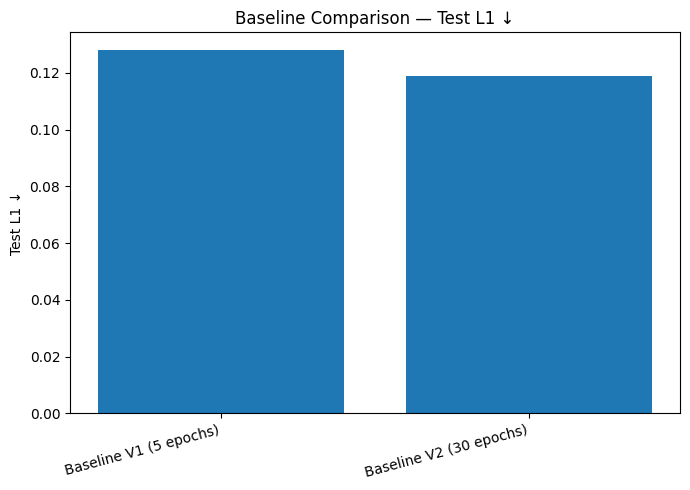

Saved: /content/MP1_IR2RGB/results/review1_test_l1.png


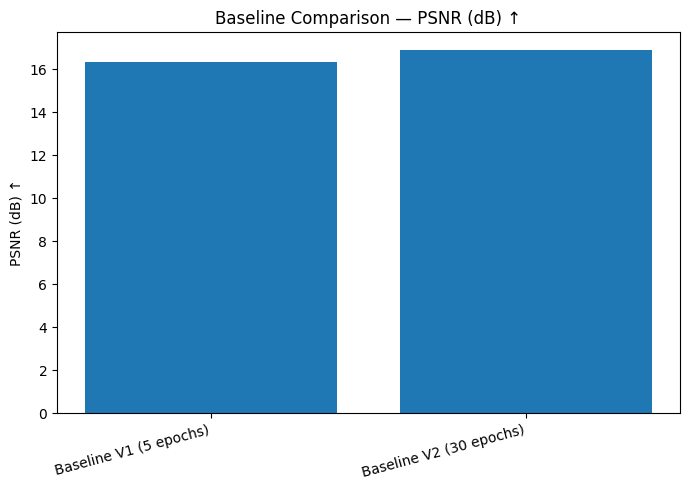

Saved: /content/MP1_IR2RGB/results/review1_psnr_db.png


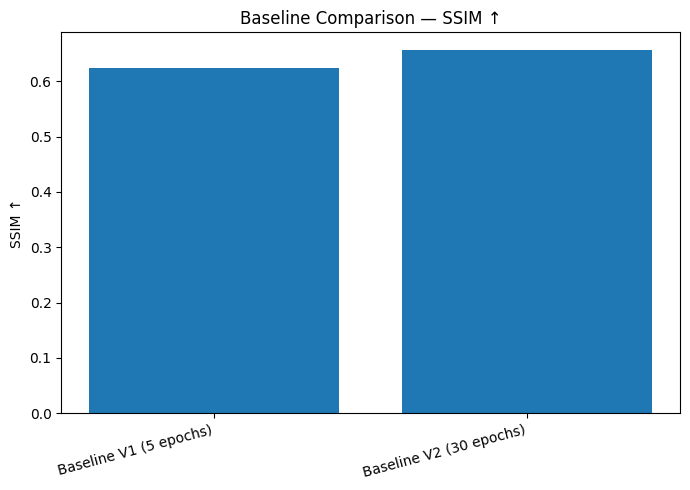

Saved: /content/MP1_IR2RGB/results/review1_ssim.png


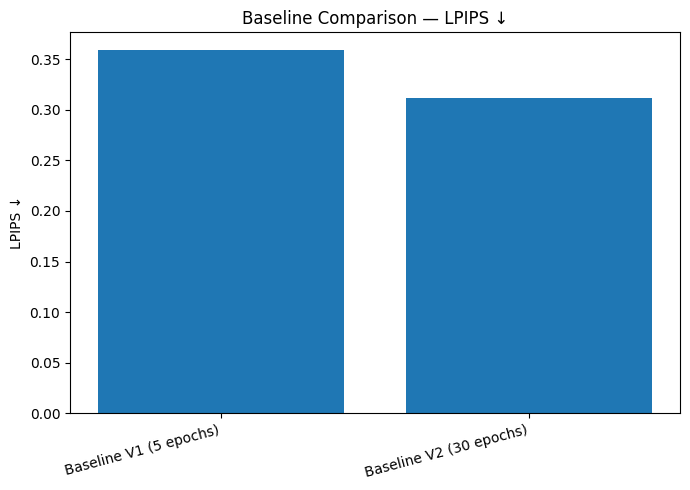

Saved: /content/MP1_IR2RGB/results/review1_lpips.png

STATUS: REVIEW 1 METRIC PLOTS GENERATED


In [69]:
# ============================================================
# REVIEW 1 — FINAL V1 vs V2 METRIC COMPARISON
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

comparison_path = (
    PROJECT_ROOT /
    "results" /
    "baseline_v1_vs_v2_comparison.csv"
)

comparison = pd.read_csv(comparison_path)

print("========== V1 vs V2 ==========")
display(comparison)

# ------------------------------------------------------------
# Create individual metric plots
# ------------------------------------------------------------

metrics = [
    ("Test L1", "Test L1 ↓", "lower"),
    ("PSNR (dB)", "PSNR (dB) ↑", "higher"),
    ("SSIM", "SSIM ↑", "higher"),
    ("LPIPS", "LPIPS ↓", "lower")
]

for column, title, direction in metrics:

    plt.figure(figsize=(7, 5))

    plt.bar(
        comparison["Model"],
        comparison[column]
    )

    plt.ylabel(title)
    plt.title(f"Baseline Comparison — {title}")

    plt.xticks(
        rotation=15,
        ha="right"
    )

    plt.tight_layout()

    output_path = (
        PROJECT_ROOT /
        "results" /
        f"review1_{column.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')}.png"
    )

    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", output_path)

print("\nSTATUS: REVIEW 1 METRIC PLOTS GENERATED")

In [70]:
# ============================================================
# REVIEW 1 — MASTER EXPERIMENT SUMMARY
# ============================================================

import pandas as pd

review1_summary = pd.DataFrame([
    {
        "Component": "Dataset",
        "Status": "Complete",
        "Result": "EPFL RGB-NIR Scene Dataset — 477 paired images"
    },
    {
        "Component": "Dataset split",
        "Status": "Complete",
        "Result": "334 train / 71 validation / 72 test"
    },
    {
        "Component": "Baseline architecture",
        "Status": "Complete",
        "Result": "IR2RGB U-Net"
    },
    {
        "Component": "Baseline V1",
        "Status": "Complete",
        "Result": "5 epochs"
    },
    {
        "Component": "Baseline V2",
        "Status": "Complete",
        "Result": "30 epochs; best checkpoint at epoch 30"
    },
    {
        "Component": "V2 Test L1",
        "Status": "Complete",
        "Result": "0.114268"
    },
    {
        "Component": "V2 PSNR",
        "Status": "Complete",
        "Result": "17.2145 dB"
    },
    {
        "Component": "V2 SSIM",
        "Status": "Complete",
        "Result": "0.6603"
    },
    {
        "Component": "V2 LPIPS",
        "Status": "Complete",
        "Result": "0.2944"
    },
    {
        "Component": "Qualitative evaluation",
        "Status": "Complete",
        "Result": "6 representative V2 comparisons"
    },
    {
        "Component": "Failure-case analysis",
        "Status": "Complete",
        "Result": "72-image test distribution analyzed"
    },
    {
        "Component": "Foundation-model-guided model",
        "Status": "Planned",
        "Result": "Next major-project phase"
    }
])

print("====================================================")
print("             REVIEW 1 MASTER SUMMARY")
print("====================================================")

display(review1_summary)

summary_path = (
    PROJECT_ROOT /
    "results" /
    "review1_master_summary.csv"
)

review1_summary.to_csv(
    summary_path,
    index=False
)

print("\nSaved to:")
print(summary_path)

print("\nSTATUS: REVIEW 1 MASTER SUMMARY SAVED")

             REVIEW 1 MASTER SUMMARY


,Component,Status,Result
0,Dataset,Complete,EPFL RGB-NIR Scene Dataset — 477 paired images
1,Dataset split,Complete,334 train / 71 validation / 72 test
2,Baseline architecture,Complete,IR2RGB U-Net
3,Baseline V1,Complete,5 epochs
4,Baseline V2,Complete,30 epochs; best checkpoint at epoch 30
5,V2 Test L1,Complete,0.114268
6,V2 PSNR,Complete,17.2145 dB
7,V2 SSIM,Complete,0.6603
8,V2 LPIPS,Complete,0.2944
9,Qualitative evaluation,Complete,6 representative V2 comparisons



Saved to:
/content/MP1_IR2RGB/results/review1_master_summary.csv

STATUS: REVIEW 1 MASTER SUMMARY SAVED


In [71]:
!ls -lah /content/MP1_IR2RGB

total 36K
drwxr-xr-x 9 root root 4.0K Sep 24 10:26 .
drwxr-xr-x 1 root root 4.0K Sep 24 10:26 ..
drwxr-xr-x 2 root root 4.0K Sep 24 10:38 checkpoints
drwxr-xr-x 2 root root 4.0K Sep 24 10:26 configs
drwxr-xr-x 3 root root 4.0K Sep 24 10:26 data
drwxr-xr-x 2 root root 4.0K Sep 24 10:26 outputs
drwxr-xr-x 4 root root 4.0K Sep 24 10:53 results
drwxr-xr-x 2 root root 4.0K Sep 24 10:26 scripts
drwxr-xr-x 2 root root 4.0K Sep 24 10:26 src


In [72]:
%cd /content/MP1_IR2RGB

/content/MP1_IR2RGB


In [73]:
!pwd

/content/MP1_IR2RGB


In [74]:
!find /content -maxdepth 3 -type d -iname "*IR2RGB*" 2>/dev/null

/content/MP1_IR2RGB


In [75]:
!find /content -maxdepth 4 -type f \( -name "*.pth" -o -name "*.pt" -o -name "*.ckpt" \) 2>/dev/null

/content/MP1_IR2RGB/checkpoints/baseline_v2_best.pth
/content/MP1_IR2RGB/checkpoints/baseline_best.pth


In [76]:
!ls -lah /content

total 24K
drwxr-xr-x 1 root root 4.0K Sep 24 10:26 .
drwxr-xr-x 1 root root 4.0K Sep 24 10:21 ..
drwxr-xr-x 4 root root 4.0K Sep  4 13:32 .config
drwx------ 5 root root 4.0K Sep 24 10:26 drive
drwxr-xr-x 9 root root 4.0K Sep 24 10:26 MP1_IR2RGB
drwxr-xr-x 1 root root 4.0K Sep  4 13:32 sample_data


In [77]:
!find /content/MP1_IR2RGB -type f | sort

/content/MP1_IR2RGB/checkpoints/baseline_best.pth
/content/MP1_IR2RGB/checkpoints/baseline_v2_best.pth
/content/MP1_IR2RGB/data/EPFL_RGB_NIR/dataset_manifest.csv
/content/MP1_IR2RGB/data/EPFL_RGB_NIR/test/nir/country_0017_nir.tiff
/content/MP1_IR2RGB/data/EPFL_RGB_NIR/test/nir/country_0022_nir.tiff
/content/MP1_IR2RGB/data/EPFL_RGB_NIR/test/nir/country_0025_nir.tiff
/content/MP1_IR2RGB/data/EPFL_RGB_NIR/test/nir/country_0032_nir.tiff
/content/MP1_IR2RGB/data/EPFL_RGB_NIR/test/nir/country_0034_nir.tiff
/content/MP1_IR2RGB/data/EPFL_RGB_NIR/test/nir/country_0041_nir.tiff
/content/MP1_IR2RGB/data/EPFL_RGB_NIR/test/nir/country_0043_nir.tiff
/content/MP1_IR2RGB/data/EPFL_RGB_NIR/test/nir/country_0050_nir.tiff
/content/MP1_IR2RGB/data/EPFL_RGB_NIR/test/nir/field_0012_nir.tiff
/content/MP1_IR2RGB/data/EPFL_RGB_NIR/test/nir/field_0016_nir.tiff
/content/MP1_IR2RGB/data/EPFL_RGB_NIR/test/nir/field_0029_nir.tiff
/content/MP1_IR2RGB/data/EPFL_RGB_NIR/test/nir/field_0031_nir.tiff
/content/MP1_IR2RG

In [78]:
!du -h --max-depth=2 /content/MP1_IR2RGB | sort -h

4.0K	/content/MP1_IR2RGB/configs
4.0K	/content/MP1_IR2RGB/outputs
4.0K	/content/MP1_IR2RGB/scripts
4.0K	/content/MP1_IR2RGB/src
6.1M	/content/MP1_IR2RGB/results/qualitative_baseline_v2
7.0M	/content/MP1_IR2RGB/results/qualitative_baseline
20M	/content/MP1_IR2RGB/results
711M	/content/MP1_IR2RGB/checkpoints
1.3G	/content/MP1_IR2RGB/data
1.3G	/content/MP1_IR2RGB/data/EPFL_RGB_NIR
2.0G	/content/MP1_IR2RGB


In [79]:
!ls -lh /content/MP1_IR2RGB/checkpoints/


total 711M
-rw-r--r-- 1 root root 356M Sep 24 10:35 baseline_best.pth
-rw-r--r-- 1 root root 356M Sep 24 10:43 baseline_v2_best.pth


In [80]:
%cd /content/MP1_IR2RGB
!mkdir -p Base_Model

/content/MP1_IR2RGB


In [81]:
!ls -lah

total 40K
drwxr-xr-x 10 root root 4.0K Sep 24 10:57 .
drwxr-xr-x  1 root root 4.0K Sep 24 10:26 ..
drwxr-xr-x  2 root root 4.0K Sep 24 10:57 Base_Model
drwxr-xr-x  2 root root 4.0K Sep 24 10:38 checkpoints
drwxr-xr-x  2 root root 4.0K Sep 24 10:26 configs
drwxr-xr-x  3 root root 4.0K Sep 24 10:26 data
drwxr-xr-x  2 root root 4.0K Sep 24 10:26 outputs
drwxr-xr-x  4 root root 4.0K Sep 24 10:53 results
drwxr-xr-x  2 root root 4.0K Sep 24 10:26 scripts
drwxr-xr-x  2 root root 4.0K Sep 24 10:26 src


In [82]:
%cd /content/MP1_IR2RGB

!mkdir -p Base_Model/src
!mkdir -p Base_Model/scripts
!mkdir -p Base_Model/configs
!mkdir -p Base_Model/checkpoints
!mkdir -p Base_Model/results

/content/MP1_IR2RGB


In [83]:
!find Base_Model -maxdepth 2 -type d | sort




Base_Model
Base_Model/checkpoints
Base_Model/configs
Base_Model/results
Base_Model/scripts
Base_Model/src


In [84]:
%cd /content/MP1_IR2RGB

print("========== SRC ==========")
!find src -maxdepth 2 -type f | sort

print("\n========== SCRIPTS ==========")
!find scripts -maxdepth 2 -type f | sort

print("\n========== CONFIGS ==========")
!find configs -maxdepth 2 -type f | sort

print("\n========== RESULTS ==========")
!find results -maxdepth 2 -type f | sort

/content/MP1_IR2RGB
========== SRC ==========

========== SCRIPTS ==========

========== CONFIGS ==========

========== RESULTS ==========
results/baseline_metrics_summary.csv
results/baseline_per_image_metrics.csv
results/baseline_qualitative_contact_sheet.png
results/baseline_training_history.csv
results/baseline_v1_vs_v2_comparison.csv
results/baseline_v2_training_history.csv
results/official_baseline_v2_results.csv
results/qualitative_baseline/country_0017_comparison.png
results/qualitative_baseline/field_0029_comparison.png
results/qualitative_baseline/forest_0047_comparison.png
results/qualitative_baseline/indoor_0035_comparison.png
results/qualitative_baseline/mountain_0042_comparison.png
results/qualitative_baseline/street_0037_comparison.png
results/qualitative_baseline_v2/country_0017_v2_comparison.png
results/qualitative_baseline_v2/field_0050_v2_comparison.png
results/qualitative_baseline_v2/indoor_0022_v2_comparison.png
results/qualitative_baseline_v2/oldbuilding_0061_v2_c

In [85]:
%cd /content/MP1_IR2RGB

print("========== ALL PYTHON FILES ==========")
!find . -type f -name "*.py" \
    -not -path "./data/*" \
    -not -path "./checkpoints/*" | sort

print("\n========== ALL NOTEBOOKS ==========")
!find . -type f \( -name "*.ipynb" -o -name "*.py" \) \
    -not -path "./data/*" \
    -not -path "./checkpoints/*" | sort

print("\n========== ROOT FILES ==========")
!find . -maxdepth 1 -type f -print | sort

/content/MP1_IR2RGB
========== ALL PYTHON FILES ==========

========== ALL NOTEBOOKS ==========

========== ROOT FILES ==========


In [86]:
%cd /content/MP1_IR2RGB

!cp -r results/* Base_Model/results/

/content/MP1_IR2RGB


In [87]:
!find Base_Model/results -type f | sort

Base_Model/results/baseline_metrics_summary.csv
Base_Model/results/baseline_per_image_metrics.csv
Base_Model/results/baseline_qualitative_contact_sheet.png
Base_Model/results/baseline_training_history.csv
Base_Model/results/baseline_v1_vs_v2_comparison.csv
Base_Model/results/baseline_v2_training_history.csv
Base_Model/results/official_baseline_v2_results.csv
Base_Model/results/qualitative_baseline/country_0017_comparison.png
Base_Model/results/qualitative_baseline/field_0029_comparison.png
Base_Model/results/qualitative_baseline/forest_0047_comparison.png
Base_Model/results/qualitative_baseline/indoor_0035_comparison.png
Base_Model/results/qualitative_baseline/mountain_0042_comparison.png
Base_Model/results/qualitative_baseline/street_0037_comparison.png
Base_Model/results/qualitative_baseline_v2/country_0017_v2_comparison.png
Base_Model/results/qualitative_baseline_v2/field_0050_v2_comparison.png
Base_Model/results/qualitative_baseline_v2/indoor_0022_v2_comparison.png
Base_Model/resul

In [88]:
%cd /content/MP1_IR2RGB

!cp checkpoints/baseline_best.pth Base_Model/checkpoints/
!cp checkpoints/baseline_v2_best.pth Base_Model/checkpoints/

/content/MP1_IR2RGB


In [89]:
!ls -lh Base_Model/checkpoints/

total 711M
-rw-r--r-- 1 root root 356M Sep 24 11:25 baseline_best.pth
-rw-r--r-- 1 root root 356M Sep 24 11:25 baseline_v2_best.pth


In [90]:
!find Base_Model -maxdepth 3 -type f | sort

Base_Model/checkpoints/baseline_best.pth
Base_Model/checkpoints/baseline_v2_best.pth
Base_Model/results/baseline_metrics_summary.csv
Base_Model/results/baseline_per_image_metrics.csv
Base_Model/results/baseline_qualitative_contact_sheet.png
Base_Model/results/baseline_training_history.csv
Base_Model/results/baseline_v1_vs_v2_comparison.csv
Base_Model/results/baseline_v2_training_history.csv
Base_Model/results/official_baseline_v2_results.csv
Base_Model/results/qualitative_baseline/country_0017_comparison.png
Base_Model/results/qualitative_baseline/field_0029_comparison.png
Base_Model/results/qualitative_baseline/forest_0047_comparison.png
Base_Model/results/qualitative_baseline/indoor_0035_comparison.png
Base_Model/results/qualitative_baseline/mountain_0042_comparison.png
Base_Model/results/qualitative_baseline/street_0037_comparison.png
Base_Model/results/qualitative_baseline_v2/country_0017_v2_comparison.png
Base_Model/results/qualitative_baseline_v2/field_0050_v2_comparison.png
Base